# Analyse par Seuils — Zone Blanche / LOS / Couverture Technologique
**Projet FerroMobile / Flexy** — UTBM FEMTO-ST DISC/OMNI  
Ligne ferroviaire 785000 · Courpière–Ambert · 30 km

**Approche** : classification directe par seuils physiques (sans Machine Learning).

Le ML a été retiré : le label `zone_blanche` (et indirectement `los_category`) est défini
à partir des mêmes seuils que les features radio (`debit_adj_mbps`, `snr_adjusted_db`).
Entraîner un classifieur revient à ré-apprendre une règle déterministe — c'est du data leakage,
même en excluant les colonnes radio des features (les proxys comme `dist_ant_km` ou
`n_antennas` restent corrélés au seuil). On affiche donc directement la règle de seuil.

Ce notebook contient :
- **Partie 1** — Zone Blanche / Zone Couverte (seuil débit/SNR)
- **Partie 2** — Classification LOS (seuil terrain / visibilité)
- **Partie 3** — Couverture par technologie 2G / 3G / 4G / 5G (tronçons couverts)


In [1]:
# Installer les paquets manquants (si nécessaire)
%pip install -q pandas numpy matplotlib

# ── Imports ──────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── Config ───────────────────────────────────────────────────────────────────
BASE_DIR = os.path.dirname(os.getcwd())
DATASET_PATH = os.path.join(BASE_DIR, "data", "processed", "dataset_enrichi.csv")

SEED = 42
np.random.seed(SEED)

print("✓ Imports OK")
print(f"✓ Dataset path : {DATASET_PATH}")
print(f"✓ Fichier trouvé : {os.path.exists(DATASET_PATH)}")


Note: you may need to restart the kernel to use updated packages.
✓ Imports OK
✓ Dataset path : /home/meyssem/Documents/ferromobile_project/data/processed/dataset_enrichi.csv
✓ Fichier trouvé : True


In [2]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
print(f"Dataset brut : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Points GPS uniques : {df['point_id'].nunique()}")
print(f"Générations : {sorted(df['generation'].unique())}")
print(f"Opérateurs   : {sorted(df['operateur'].unique())}")


Dataset brut : 28845 lignes × 73 colonnes
Points GPS uniques : 1923
Générations : ['2G', '3G', '4G', '5G']
Opérateurs   : ['BOUYGUES TELECOM', 'FREE MOBILE', 'ORANGE', 'SFR']


---
# Partie 1 — Zone Blanche / Zone Couverte (par seuil)


## Définition du seuil

**Alignement avec `enrich_data.py::recalculate_zone_blanche`** (définition finale et
faisant référence dans le pipeline — `prepare_data.py` calcule une version intermédiaire
basée sur `qualite_ok` à 3 critères débit/SNR/RTT, mais celle-ci est **écrasée** en aval
par `enrich_data.py`, qui ne garde que le critère débit seul).

Un point est en **zone blanche** s'il n'existe, parmi toutes les antennes **cellulaires
(2G/3G/4G/5G)** disponibles à ce point hors tunnel, **aucun débit utile** au-dessus du
seuil de service minimal (`DEBIT_VIABLE_MBPS`, **1 Mbps**).

Règle exacte du pipeline :
- LoRa est **exclu** du calcul de `best_debit` (généra·trice de débit non pertinente pour
  la définition cellulaire de la zone blanche — `enrich_data.py` l'exclut explicitement,
  même si LoRa a été supprimé du dataset final actuel).
- Tunnel → `zone_blanche = 1` systématiquement (absence totale de signal cellulaire par
  construction, ARCEP §2.3), **indépendamment du débit mesuré**.
- Hors tunnel → `zone_blanche = 1` si `max(debit_adj_mbps sur generation ∈ {2G,3G,4G,5G}) < SEUIL_DEBIT_MBPS`.

⚠️ Ne pas confondre avec `DEBIT_MIN_MBPS = 5.0` / `DEBIT_MIN_PAR_GEN`, qui servent au calcul
de `qualite_ok` (qualité de service par techno) — un concept différent de la couverture
binaire zone blanche / zone couverte.

## ⚙️ Paramètre expérimental — Seuil de débit augmenté

Modifier `SEUIL_DEBIT_MBPS` ci-dessous pour tester différents seuils et observer l'impact sur la zone blanche.

| Seuil | Interprétation |
|-------|----------------|
| **1 Mbps** | Seuil minimal actuel (pipeline `enrich_data.py`) |
| **3 Mbps** | Connexion confortable (streaming audio HD) |
| **5 Mbps** | Seuil `DEBIT_MIN_MBPS` du pipeline (qualité IoT) |
| **10 Mbps** | Vidéo HD temps réel (surveillance train) |
| **20 Mbps** | Haut débit ferroviaire (WiFi passagers) |

> **Observation attendue** : à seuil plus élevé → plus de points `best_debit < SEUIL` → plus de zone blanche hors tunnel.

In [3]:
SEUIL_DEBIT_MBPS = 1.0   # ← MODIFIEZ ICI : 1.0 / 3.0 / 5.0 / 10.0 / 20.0 Mbps

# Alignement strict avec enrich_data.py::recalculate_zone_blanche :
#   - uniquement les générations cellulaires (LoRa exclu, même si absent du dataset actuel)
#   - uniquement les lignes hors tunnel pour le calcul de best_debit
#   - tunnel forcé à zone_blanche=1 indépendamment du débit
CELL_GENERATIONS = ['2G', '3G', '4G', '5G']

mask_cell_hors_tunnel = df['generation'].isin(CELL_GENERATIONS) & (~df['in_tunnel'])

best_debit_cell = (
    df.loc[mask_cell_hors_tunnel]
      .groupby('point_id')['debit_adj_mbps']
      .max()
)

by_point_zb = df.groupby('point_id').agg(
    lat          = ('lat',            'first'),
    lon          = ('lon',            'first'),
    distance_km  = ('distance_km',    'first'),
    altitude_m   = ('altitude_m',     'first'),
    in_tunnel    = ('in_tunnel',      'max'),
    best_snr     = ('snr_adjusted_db','max'),
    zone_blanche_label = ('zone_blanche', 'max'),  # label déjà présent dans le pipeline (référence)
).reset_index()

by_point_zb['best_debit'] = by_point_zb['point_id'].map(best_debit_cell)
# Points hors tunnel sans aucune antenne cellulaire : aucune ligne ne matche mask_cell_hors_tunnel
# → best_debit NaN, traité comme zone blanche (cohérent avec zb_map.fillna(1) du pipeline)
by_point_zb['best_debit'] = by_point_zb['best_debit'].fillna(0.0)

# Classification directe par seuil — tunnel toujours prioritaire sur le débit
by_point_zb['zone_blanche_seuil'] = np.where(
    by_point_zb['in_tunnel'],
    1,
    (by_point_zb['best_debit'] < SEUIL_DEBIT_MBPS).astype(int)
)

by_point_zb = by_point_zb.sort_values('distance_km').reset_index(drop=True)

n_total    = len(by_point_zb)
n_blanche  = by_point_zb['zone_blanche_seuil'].sum()
n_couverte = n_total - n_blanche

print(f"Seuil débit utilisé : {SEUIL_DEBIT_MBPS} Mbps (cellulaire uniquement, LoRa exclu)\n")
print(f"Zone couverte (seuil) : {n_couverte:4d} points ({n_couverte/n_total*100:.1f}%)")
print(f"Zone blanche  (seuil) : {n_blanche:4d} points ({n_blanche/n_total*100:.1f}%)")

# Comparaison avec le label déjà présent dans le pipeline (sanity check, pas du leakage : aucun modèle entraîné)
accord = (by_point_zb['zone_blanche_seuil'] == by_point_zb['zone_blanche_label']).mean()
print(f"\nAccord seuil vs label pipeline : {accord*100:.1f}%")
if accord < 0.999:
    desaccord = by_point_zb[by_point_zb['zone_blanche_seuil'] != by_point_zb['zone_blanche_label']]
    print(f"⚠ {len(desaccord)} points en désaccord — à investiguer avant de poursuivre l'EDA :")
    print(desaccord[['point_id', 'distance_km', 'in_tunnel', 'best_debit', 'zone_blanche_seuil', 'zone_blanche_label']].head(10))


Seuil débit utilisé : 1.0 Mbps (cellulaire uniquement, LoRa exclu)

Zone couverte (seuil) : 1752 points (91.1%)
Zone blanche  (seuil) :  171 points (8.9%)

Accord seuil vs label pipeline : 100.0%


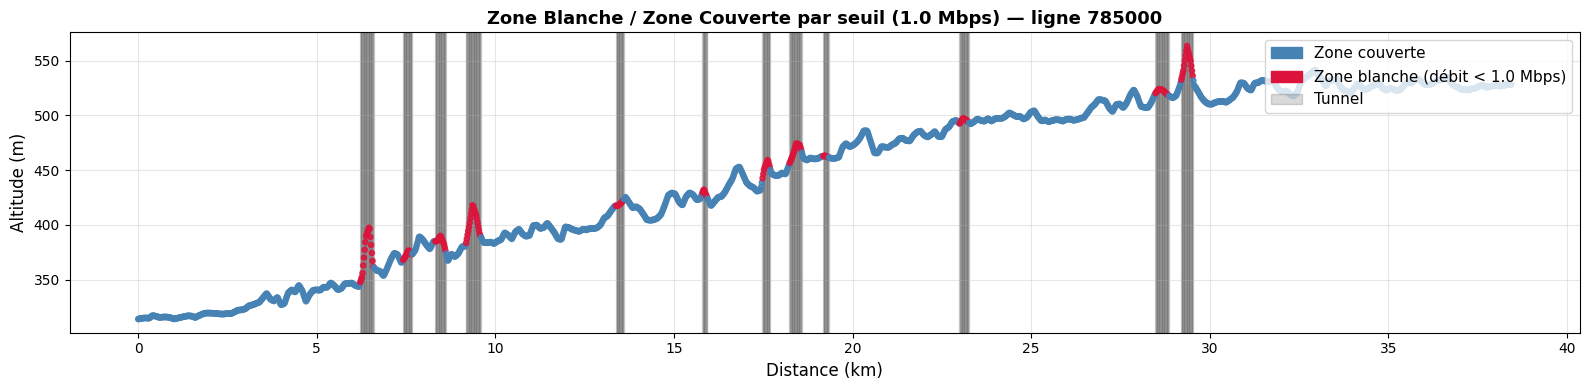

Carte sauvegardée : zone_blanche_seuil.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 4))

colors = by_point_zb['zone_blanche_seuil'].map({0: 'steelblue', 1: 'crimson'})
ax.scatter(by_point_zb['distance_km'], by_point_zb['altitude_m'],
           c=colors, s=14, alpha=0.85, zorder=3)

# Tunnels en fond gris
for _, row in by_point_zb[by_point_zb['in_tunnel']].iterrows():
    ax.axvspan(row['distance_km'] - 0.01, row['distance_km'] + 0.01,
               alpha=0.15, color='black', zorder=1)

legend_els = [
    Patch(color='steelblue', label='Zone couverte'),
    Patch(color='crimson',   label=f'Zone blanche (débit < {SEUIL_DEBIT_MBPS} Mbps)'),
    Patch(color='black', alpha=0.15, label='Tunnel'),
]
ax.legend(handles=legend_els, fontsize=11, loc='upper right')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Altitude (m)', fontsize=12)
ax.set_title(f'Zone Blanche / Zone Couverte par seuil ({SEUIL_DEBIT_MBPS} Mbps) — ligne 785000',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zone_blanche_seuil.png', dpi=150, bbox_inches='tight')
plt.show()
print("Carte sauvegardée : zone_blanche_seuil.png")


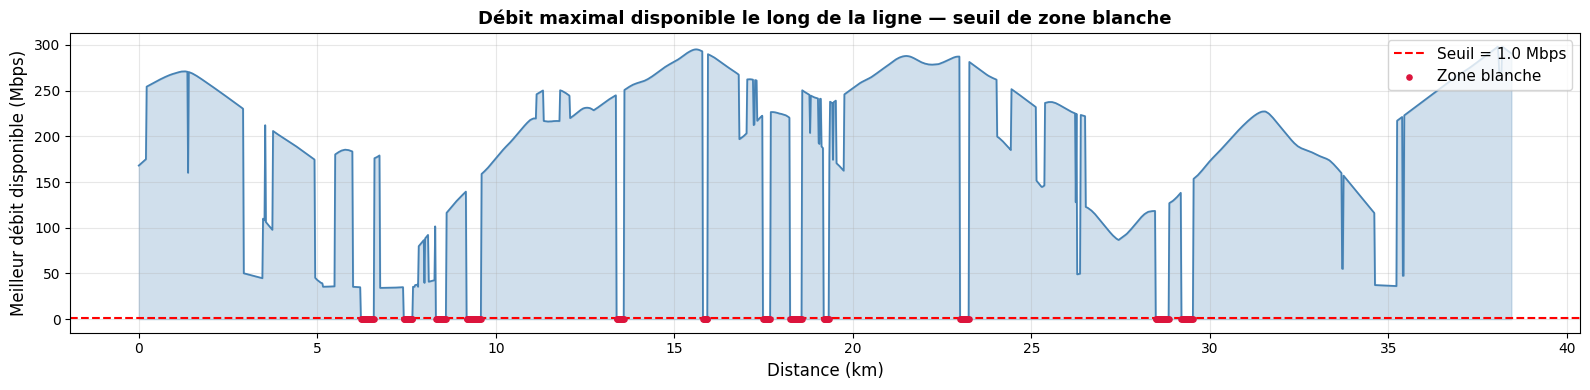

Sauvegardé : zone_blanche_debit_profil.png


In [5]:
# Débit max le long de la ligne avec ligne de seuil
fig, ax = plt.subplots(figsize=(16, 4))

ax.fill_between(by_point_zb['distance_km'], by_point_zb['best_debit'],
                alpha=0.25, color='steelblue')
ax.plot(by_point_zb['distance_km'], by_point_zb['best_debit'],
        color='steelblue', lw=1.3)

ax.axhline(SEUIL_DEBIT_MBPS, color='red', lw=1.5, ls='--',
           label=f'Seuil = {SEUIL_DEBIT_MBPS} Mbps')

mask_blanche = by_point_zb['zone_blanche_seuil'] == 1
ax.scatter(by_point_zb.loc[mask_blanche, 'distance_km'],
           by_point_zb.loc[mask_blanche, 'best_debit'],
           color='crimson', s=14, zorder=4, label='Zone blanche')

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Meilleur débit disponible (Mbps)', fontsize=12)
ax.set_title('Débit maximal disponible le long de la ligne — seuil de zone blanche',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zone_blanche_debit_profil.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : zone_blanche_debit_profil.png")


### Comparaison multi-seuils — impact sur la zone blanche


Seuil (Mbps)      Zone blanche   Zone couverte   % blanche
------------------------------------------------------------
1.0                        171            1752        8.9%  ← actuel
3.0                        171            1752        8.9%
5.0                        171            1752        8.9%
10.0                       171            1752        8.9%
20.0                       171            1752        8.9%


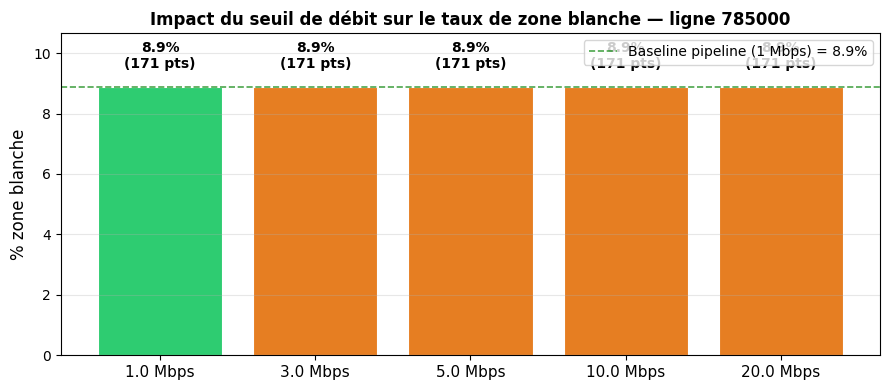

Sauvegardé : comparaison_seuils_zone_blanche.png


In [6]:
# ── Comparaison multi-seuils : impact sur le taux de zone blanche ──────────
SEUILS_A_TESTER = [1.0, 3.0, 5.0, 10.0, 20.0]

print(f"{'Seuil (Mbps)':<15} {'Zone blanche':>14} {'Zone couverte':>15} {'% blanche':>11}")
print("-" * 60)

resultats_seuils = []
for s in SEUILS_A_TESTER:
    zb = np.where(
        by_point_zb['in_tunnel'],
        1,
        (by_point_zb['best_debit'] < s).astype(int)
    )
    n_blanche_s  = zb.sum()
    n_couverte_s = n_total - n_blanche_s
    pct_blanche  = n_blanche_s / n_total * 100
    marker = '  ← actuel' if s == SEUIL_DEBIT_MBPS else ''
    print(f"{s:<15.1f} {n_blanche_s:>14} {n_couverte_s:>15} {pct_blanche:>10.1f}%{marker}")
    resultats_seuils.append((s, n_blanche_s, pct_blanche))

# Graphique comparatif
fig, ax = plt.subplots(figsize=(9, 4))
seuils_vals = [r[0] for r in resultats_seuils]
pct_vals    = [r[2] for r in resultats_seuils]

bars = ax.bar(range(len(seuils_vals)), pct_vals,
              color=['#2ecc71' if s == 1.0 else '#e74c3c' if pct > 50 else '#e67e22'
                     for s, pct in zip(seuils_vals, pct_vals)],
              edgecolor='white', linewidth=0.8)

for bar, (s, n, pct) in zip(bars, resultats_seuils):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%\n({n} pts)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(resultats_seuils[0][2], color='green', lw=1.2, ls='--', alpha=0.7,
           label=f'Baseline pipeline (1 Mbps) = {resultats_seuils[0][2]:.1f}%')

ax.set_xticks(range(len(seuils_vals)))
ax.set_xticklabels([f'{s} Mbps' for s in seuils_vals], fontsize=11)
ax.set_ylabel('% zone blanche', fontsize=12)
ax.set_ylim(0, max(pct_vals) * 1.2)
ax.set_title('Impact du seuil de débit sur le taux de zone blanche — ligne 785000',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('comparaison_seuils_zone_blanche.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : comparaison_seuils_zone_blanche.png")


---
# Partie 2 — Classification LOS (par seuil terrain)


## Définition et correction méthodologique

`los_category` est calculé dans le pipeline (`prepare_data.py::check_los_graduel`) pour
**chaque paire point↔antenne** à partir du profil de terrain réel (EU-DEM) et du critère
de la zone de Fresnel — ce n'est pas une métrique radio simulée, c'est un calcul géométrique
déterministe : `0=Tunnel · 1=NLOS bloqué (obstruction totale) · 2=Partiel (zone de Fresnel
obstruée) · 3=LOS dégagé`.

**Pourquoi l'altitude compte** : entre le train et une antenne, si le relief le long du
trajet dépasse la ligne droite reliant les deux (corrigée de la zone de Fresnel), le signal
est bloqué ou dégradé. C'est ce calcul géométrique qui produit la catégorie LOS.

**⚠️ Point important** : un point GPS "voit" plusieurs antennes (jusqu'à 88 candidates dans
le rayon de recherche), donc `los_category` n'est pas une propriété unique du point — elle
varie par antenne. Une agrégation par **pire cas** (`.min()`, une seule antenne lointaine
bloquée suffit à classer tout le point en NLOS) ou par **meilleur cas** (`.max()`) déforme
fortement la distribution réelle. On utilise donc :
- la **distribution brute** (toutes les paires point×antenne) pour les statistiques globales,
  qui correspond à ta référence (≈46% LOS dégagé / 12% partiel / 40% NLOS / 2% tunnel) ;
- le **mode** (catégorie la plus fréquente parmi les antennes disponibles à ce point) pour
  la carte le long de la ligne, qui donne une vue représentative sans biais pire/meilleur cas.


In [7]:
LOS_LABELS = {0: 'Tunnel', 1: 'NLOS bloqué', 2: 'Partiel/dégradé', 3: 'LOS dégagé'}
COLORS_LOS = {0: '#7f8c8d', 1: '#c0392b', 2: '#e67e22', 3: '#27ae60'}
ATTEN_DB = {0: float('-inf'), 1: -15, 2: -8, 3: 0}   # atténuation indicative par catégorie

# Distribution brute (point × antenne) — référence pour les statistiques globales
dist_brute = df['los_category'].value_counts(normalize=True).sort_index() * 100

print("Distribution LOS brute (toutes paires point × antenne) :")
for cat, label in LOS_LABELS.items():
    pct = dist_brute.get(cat, 0.0)
    print(f"  {cat} — {label:18s} : {pct:5.1f}%")

# Agrégation par point — mode (catégorie la plus fréquente parmi les antennes disponibles)
# (.min() = pire cas et .max() = meilleur cas déforment la distribution ; le mode est représentatif)
by_point_los = df.groupby('point_id').agg(
    lat          = ('lat',          'first'),
    lon          = ('lon',          'first'),
    distance_km  = ('distance_km',  'first'),
    altitude_m   = ('altitude_m',   'first'),
    in_tunnel    = ('in_tunnel',    'max'),
    dist_ant_km  = ('dist_ant_km',  'min'),
).reset_index()

mode_los = df.groupby('point_id')['los_category'].agg(lambda x: x.mode().iloc[0])
by_point_los = by_point_los.merge(mode_los.rename('los_category'), on='point_id')
by_point_los = by_point_los.sort_values('distance_km').reset_index(drop=True)

print("\nDistribution LOS par point (mode — catégorie représentative) :")
for cat, label in LOS_LABELS.items():
    n = (by_point_los['los_category'] == cat).sum()
    print(f"  {cat} — {label:18s} : {n:4d} points ({n/len(by_point_los)*100:.1f}%)")


Distribution LOS brute (toutes paires point × antenne) :
  0 — Tunnel             :   8.9%
  1 — NLOS bloqué        :   0.7%
  2 — Partiel/dégradé    :   0.2%
  3 — LOS dégagé         :  90.2%

Distribution LOS par point (mode — catégorie représentative) :
  0 — Tunnel             :  171 points (8.9%)
  1 — NLOS bloqué        :    6 points (0.3%)
  2 — Partiel/dégradé    :    1 points (0.1%)
  3 — LOS dégagé         : 1745 points (90.7%)


### Carte-résumé — distribution LOS et atténuation associée


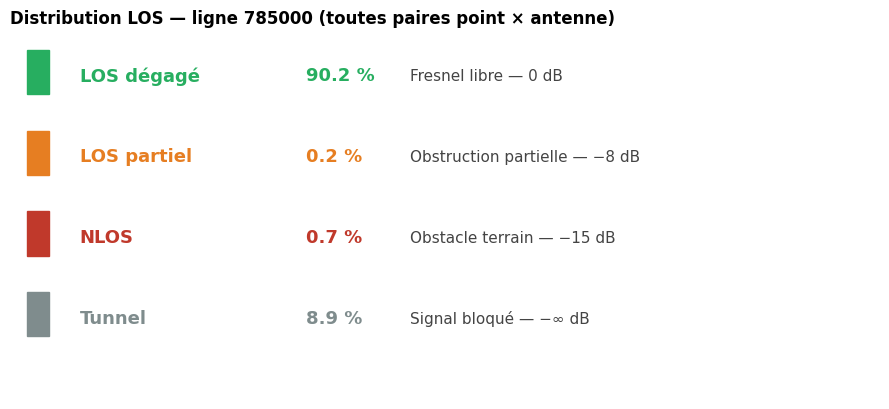

Sauvegardé : los_resume_pct_db.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axis('off')

row_labels = {0: 'Tunnel', 1: 'NLOS', 2: 'LOS partiel', 3: 'LOS dégagé'}
row_desc = {
    0: 'Signal bloqué — −∞ dB',
    1: 'Obstacle terrain — −15 dB',
    2: 'Obstruction partielle — −8 dB',
    3: 'Fresnel libre — 0 dB',
}
row_order = [3, 2, 1, 0]   # même ordre que la slide de référence

y0 = 0.88
dy = 0.22
for i, cat in enumerate(row_order):
    y = y0 - i * dy
    pct = dist_brute.get(cat, 0.0)
    color = COLORS_LOS[cat]
    ax.add_patch(plt.Rectangle((0.02, y - 0.05), 0.025, 0.12,
                                transform=ax.transAxes, color=color, clip_on=False))
    ax.text(0.08, y, row_labels[cat], transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=color, va='center')
    ax.text(0.34, y, f"{pct:.1f} %", transform=ax.transAxes,
            fontsize=13, fontweight='bold', color=color, va='center')
    ax.text(0.46, y, row_desc[cat], transform=ax.transAxes,
            fontsize=11, color='#444444', va='center')

ax.set_title('Distribution LOS — ligne 785000 (toutes paires point × antenne)',
             fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('los_resume_pct_db.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : los_resume_pct_db.png")


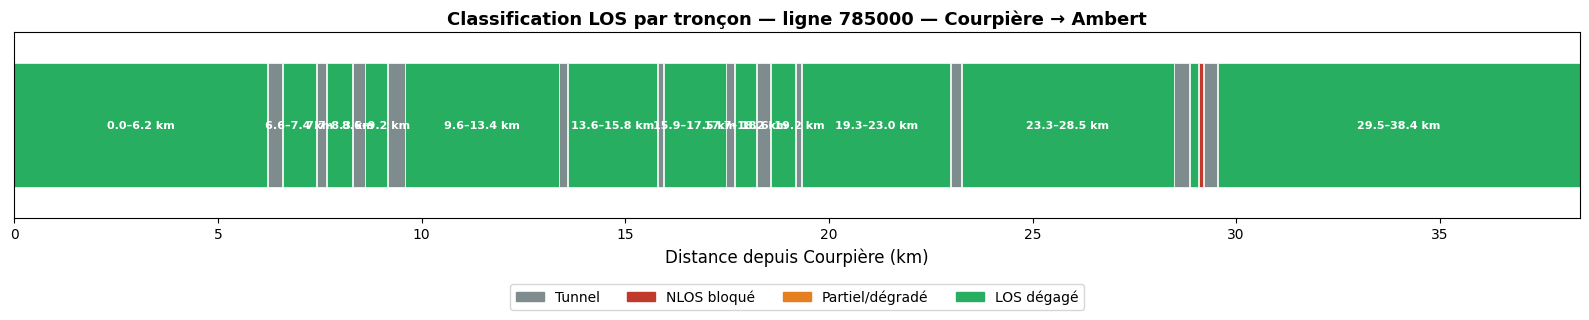

Carte sauvegardée : los_carte_troncons.png

Tronçons LOS (mode par point) :

Tunnel — 12 tronçon(s) :
   km   6.22 → km   6.58  ( 0.36 km)
   km   7.42 → km   7.66  ( 0.24 km)
   km   8.32 → km   8.60  ( 0.28 km)
   km   9.18 → km   9.58  ( 0.40 km)
   km  13.38 → km  13.58  ( 0.20 km)
   km  15.80 → km  15.92  ( 0.12 km)
   km  17.48 → km  17.68  ( 0.20 km)
   km  18.24 → km  18.56  ( 0.32 km)
   km  19.18 → km  19.32  ( 0.14 km)
   km  23.00 → km  23.24  ( 0.24 km)
   km  28.48 → km  28.84  ( 0.36 km)
   km  29.20 → km  29.52  ( 0.32 km)

NLOS bloqué — 1 tronçon(s) :
   km  29.08 → km  29.18  ( 0.10 km)

Partiel/dégradé — 1 tronçon(s) :

LOS dégagé — 13 tronçon(s) :
   km   0.00 → km   6.20  ( 6.20 km)
   km   6.60 → km   7.40  ( 0.80 km)
   km   7.68 → km   8.30  ( 0.62 km)
   km   8.62 → km   9.16  ( 0.54 km)
   km   9.60 → km  13.36  ( 3.76 km)
   km  13.60 → km  15.78  ( 2.18 km)
   km  15.94 → km  17.46  ( 1.52 km)
   km  17.70 → km  18.22  ( 0.52 km)
   km  18.58 → km  19.16  (

In [9]:
# Carte de ligne groupée en tronçons lisibles (mode par point, segments contigus)
def get_troncons_los(by_point_los, cat, gap_max=0.15):
    sub = by_point_los[by_point_los['los_category'] == cat].sort_values('distance_km')
    pts = sub['distance_km'].values
    if len(pts) == 0:
        return []
    troncons = []
    start = prev = pts[0]
    for p in pts[1:]:
        if p - prev > gap_max:
            troncons.append((start, prev))
            start = p
        prev = p
    troncons.append((start, prev))
    return troncons

fig, ax = plt.subplots(figsize=(16, 3.6))

all_segs = []
for cat in [0, 1, 2, 3]:
    for (a, b) in get_troncons_los(by_point_los, cat):
        all_segs.append((a, b, cat))

for (a, b, cat) in all_segs:
    width = max(b - a, 0.05)
    ax.barh(0, width, left=a, height=0.8, color=COLORS_LOS[cat],
            edgecolor='white', linewidth=0.5, zorder=2)

# Annotations en deux rangées alternées pour éviter les chevauchements sur les segments courts
wide_segs = [s for s in all_segs if (s[1]-s[0]) > 0.5]
for i, (a, b, cat) in enumerate(sorted(wide_segs)):
    y_off = 0 if (i % 2 == 0) else 0
    ax.text((a+b)/2, 0, f'{a:.1f}–{b:.1f} km',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold', zorder=3)

handles = [mpatches.Patch(color=COLORS_LOS[c], label=LOS_LABELS[c]) for c in [0,1,2,3]]
ax.legend(handles=handles, fontsize=10, loc='upper center',
          bbox_to_anchor=(0.5, -0.32), ncol=4)

ax.set_xlim(by_point_los['distance_km'].min(), by_point_los['distance_km'].max())
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel('Distance depuis Courpière (km)', fontsize=12)
ax.set_title('Classification LOS par tronçon — ligne 785000 — Courpière → Ambert',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('los_carte_troncons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Carte sauvegardée : los_carte_troncons.png")

print("\nTronçons LOS (mode par point) :")
for cat in [0,1,2,3]:
    troncons = get_troncons_los(by_point_los, cat)
    print(f"\n{LOS_LABELS[cat]} — {len(troncons)} tronçon(s) :")
    for (a,b) in troncons:
        if b - a > 0.05:
            print(f"   km {a:6.2f} → km {b:6.2f}  ({b-a:5.2f} km)")


---
# Partie 3 — Couverture par Technologie (2G / 3G / 4G / 5G)


## Objectif

Identifier, pour chaque génération, **quels tronçons de la ligne** sont couverts
(au-dessus du seuil de débit) et avec quelle qualité, en prenant le meilleur opérateur
disponible à chaque point.


In [10]:
COLORS_GEN = {'2G': '#e74c3c', '3G': '#f39c12', '4G': '#2980b9', '5G': '#27ae60'}

gen_coverage = df.groupby(['point_id', 'generation']).agg(
    distance_km  = ('distance_km',    'first'),
    altitude_m   = ('altitude_m',     'first'),
    lat          = ('lat',            'first'),
    lon          = ('lon',            'first'),
    in_tunnel    = ('in_tunnel',      'first'),
    best_debit   = ('debit_adj_mbps', 'max'),
    best_snr     = ('snr_adjusted_db','max'),
).reset_index()

pivot_debit = gen_coverage.pivot_table(
    index='point_id', columns='generation', values='best_debit', aggfunc='max'
).fillna(0)

geo = df.groupby('point_id').agg(
    distance_km = ('distance_km', 'first'),
    altitude_m  = ('altitude_m',  'first'),
    lat         = ('lat',         'first'),
    lon         = ('lon',         'first'),
    in_tunnel   = ('in_tunnel',   'first'),
).reset_index()

pivot_debit = pivot_debit.reset_index().merge(geo, on='point_id')
pivot_debit = pivot_debit.sort_values('distance_km').reset_index(drop=True)

print(f"Seuil de couverture utilisé : {SEUIL_DEBIT_MBPS} Mbps\n")
print("Points couverts par génération :")
for gen in ['2G','3G','4G','5G']:
    if gen in pivot_debit.columns:
        n = (pivot_debit[gen] >= SEUIL_DEBIT_MBPS).sum()
        moy = pivot_debit[gen][pivot_debit[gen] >= SEUIL_DEBIT_MBPS].mean()
        print(f"  {gen} : {n:4d} points couverts | débit moyen : {moy:6.1f} Mbps")


Seuil de couverture utilisé : 1.0 Mbps

Points couverts par génération :
  2G :    0 points couverts | débit moyen :    nan Mbps
  3G : 1730 points couverts | débit moyen :    6.9 Mbps
  4G : 1752 points couverts | débit moyen :   58.8 Mbps
  5G : 1608 points couverts | débit moyen :  217.8 Mbps


---
## Carte géographique — Infrastructure et réseau mobile

Reproduction de la carte ANFR : tracé de la voie ferrée, zone tampon, antennes par opérateur et génération.


Note: you may need to restart the kernel to use updated packages.


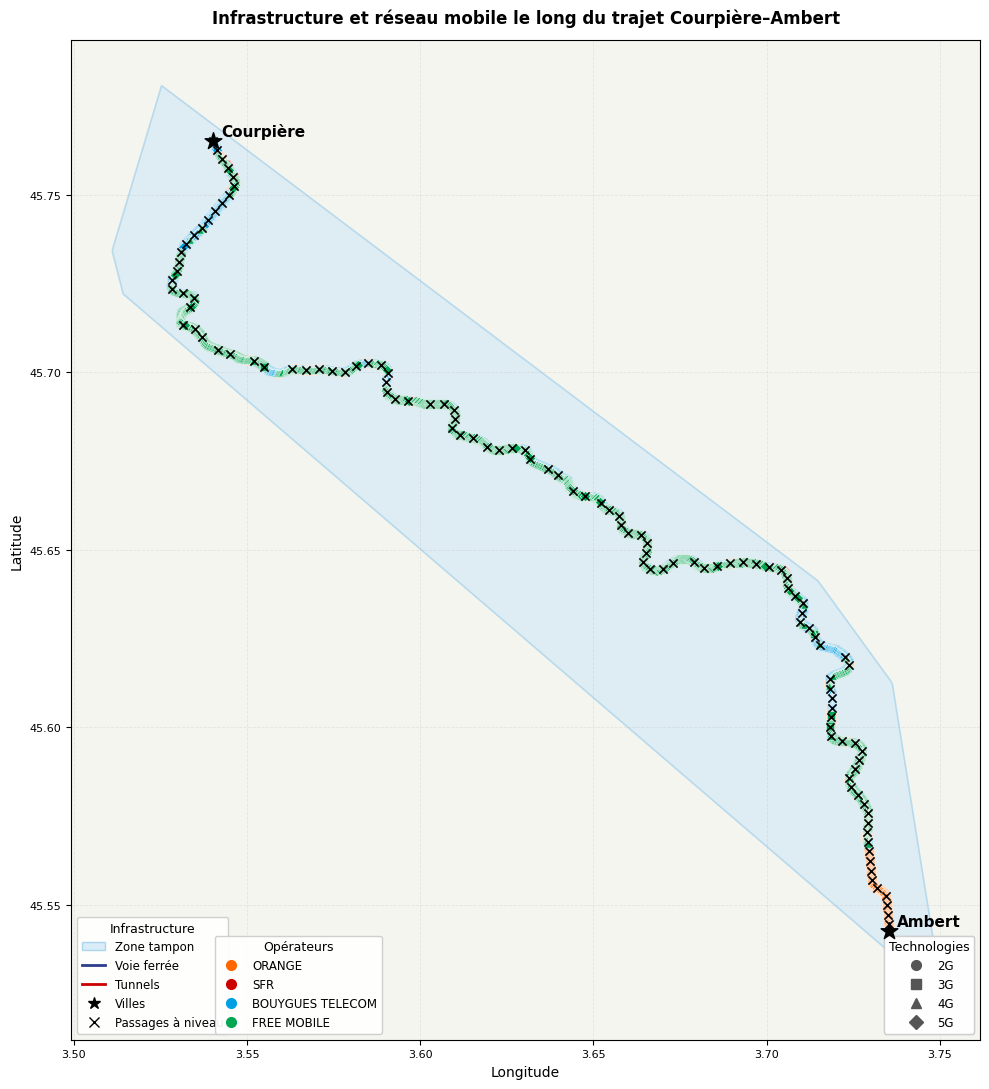

Sauvegardé : carte_reseau_mobile_ligne785000.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CARTE — Infrastructure et réseau mobile — Ligne 785000 Courpière–Ambert
# Reproduit la carte ANFR : tracé de la voie + antennes par opérateur/génération
# ═══════════════════════════════════════════════════════════════════════════
%pip install -q matplotlib numpy scipy
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── 1. Tracé de la voie ferrée (points GPS uniques triés par distance) ──────
voie = df.groupby('point_id').agg(
    lat        = ('lat',         'first'),
    lon        = ('lon',         'first'),
    distance_km= ('distance_km', 'first'),
    in_tunnel  = ('in_tunnel',   'first'),
).reset_index().sort_values('distance_km')

# ── 2. Antennes : une ligne par paire (point, opérateur, génération) ────────
antennes = df.groupby(['point_id', 'operateur', 'generation']).agg(
    lat = ('lat', 'first'),
    lon = ('lon', 'first'),
).reset_index()

# ── 3. Palettes ─────────────────────────────────────────────────────────────
COLORS_OP = {
    'ORANGE':          '#FF6600',
    'SFR':             '#CC0000',
    'BOUYGUES TELECOM': '#009FE3',
    'FREE MOBILE':     '#00A651',
}
MARKERS_GEN = {'2G': 'o', '3G': 's', '4G': '^', '5G': 'D'}
SIZES_GEN   = {'2G': 28,  '3G': 28,  '4G': 28,  '5G': 28}

# ── 4. Zone tampon (convex hull autour de la voie) ──────────────────────────
coords = voie[['lon', 'lat']].values
# Élargissement artificiel du hull pour avoir une zone tampon
center_lon = coords[:, 0].mean()
center_lat = coords[:, 1].mean()
# Expand 15% pour la zone tampon
expanded = center_lon + 1.15 * (coords[:, 0] - center_lon), \
           center_lat + 1.15 * (coords[:, 1] - center_lat)
expanded_coords = np.column_stack(expanded)
hull = ConvexHull(expanded_coords)
hull_pts = expanded_coords[hull.vertices]
hull_pts = np.vstack([hull_pts, hull_pts[0]])  # fermer le polygone

# ── 5. Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 11))
ax.set_facecolor('#f5f5f0')
fig.patch.set_facecolor('white')

# Zone tampon (remplissage bleu clair)
from matplotlib.patches import Polygon as MplPolygon
zone_patch = MplPolygon(
    hull_pts, closed=True,
    facecolor='#cce5f6', edgecolor='#90c8e8', linewidth=1.2,
    alpha=0.55, zorder=1, label='Zone tampon'
)
ax.add_patch(zone_patch)

# Voie ferrée — segments hors tunnel (bleu) et tunnel (rouge)
for i in range(len(voie) - 1):
    row  = voie.iloc[i]
    row2 = voie.iloc[i + 1]
    color = '#cc0000' if row['in_tunnel'] else '#2c3e8c'
    ax.plot([row['lon'], row2['lon']], [row['lat'], row2['lat']],
            color=color, lw=2.0, zorder=3)

# Passages à niveau — petits X noirs sur les points de la voie
# (approximation : 1 point sur 15 hors tunnel)
pnx = voie[~voie['in_tunnel']].iloc[::15]
ax.scatter(pnx['lon'], pnx['lat'],
           marker='x', color='black', s=35, lw=1.2, zorder=5, label='Passages à niveau')

# Antennes par opérateur × génération
for op, color_op in COLORS_OP.items():
    for gen, marker in MARKERS_GEN.items():
        mask = (antennes['operateur'] == op) & (antennes['generation'] == gen)
        sub = antennes[mask]
        if sub.empty:
            continue
        ax.scatter(
            sub['lon'], sub['lat'],
            marker=marker,
            color=color_op,
            s=SIZES_GEN[gen],
            alpha=0.88,
            zorder=4,
            linewidths=0.4,
            edgecolors='white',
        )

# Villes principales
VILLES = {
    'Courpière': (voie.iloc[0]['lat'],  voie.iloc[0]['lon']),
    'Ambert':    (voie.iloc[-1]['lat'], voie.iloc[-1]['lon']),
}
for ville, (vlat, vlon) in VILLES.items():
    ax.scatter(vlon, vlat, marker='*', color='black', s=160, zorder=6)
    ax.annotate(ville, (vlon, vlat), textcoords='offset points',
                xytext=(6, 4), fontsize=11, fontweight='bold', color='black')

# ── 6. Légendes ─────────────────────────────────────────────────────────────
# Légende infrastructure (gauche)
infra_handles = [
    mpatches.Patch(facecolor='#cce5f6', edgecolor='#90c8e8', label='Zone tampon', alpha=0.7),
    Line2D([0],[0], color='#2c3e8c', lw=2,  label='Voie ferrée'),
    Line2D([0],[0], color='#cc0000', lw=2,  label='Tunnels'),
    Line2D([0],[0], marker='*', color='black', linestyle='None', markersize=9, label='Villes'),
    Line2D([0],[0], marker='x', color='black', linestyle='None', markersize=7, label='Passages à niveau'),
]
leg1 = ax.legend(handles=infra_handles, title='Infrastructure',
                  loc='lower left', fontsize=8.5, title_fontsize=9,
                  framealpha=0.92, edgecolor='#cccccc')
ax.add_artist(leg1)

# Légende opérateurs (bas centre)
op_handles = [
    Line2D([0],[0], marker='o', color=c, linestyle='None',
           markersize=7, label=op)
    for op, c in COLORS_OP.items()
]
leg2 = ax.legend(handles=op_handles, title='Opérateurs',
                  loc='lower center', fontsize=8.5, title_fontsize=9,
                  framealpha=0.92, edgecolor='#cccccc',
                  bbox_to_anchor=(0.25, 0.0))
ax.add_artist(leg2)

# Légende technologies (bas droite)
tech_handles = [
    Line2D([0],[0], marker=m, color='#555555', linestyle='None',
           markersize=7, label=gen)
    for gen, m in MARKERS_GEN.items()
]
leg3 = ax.legend(handles=tech_handles, title='Technologies',
                  loc='lower right', fontsize=8.5, title_fontsize=9,
                  framealpha=0.92, edgecolor='#cccccc')
ax.add_artist(leg3)

# ── 7. Mise en page ─────────────────────────────────────────────────────────
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude',  fontsize=10)
ax.set_title(
    'Infrastructure et réseau mobile le long du trajet Courpière–Ambert',
    fontsize=12, fontweight='bold', pad=12
)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('carte_reseau_mobile_ligne785000.png', dpi=180, bbox_inches='tight')
plt.show()
print('Sauvegardé : carte_reseau_mobile_ligne785000.png')


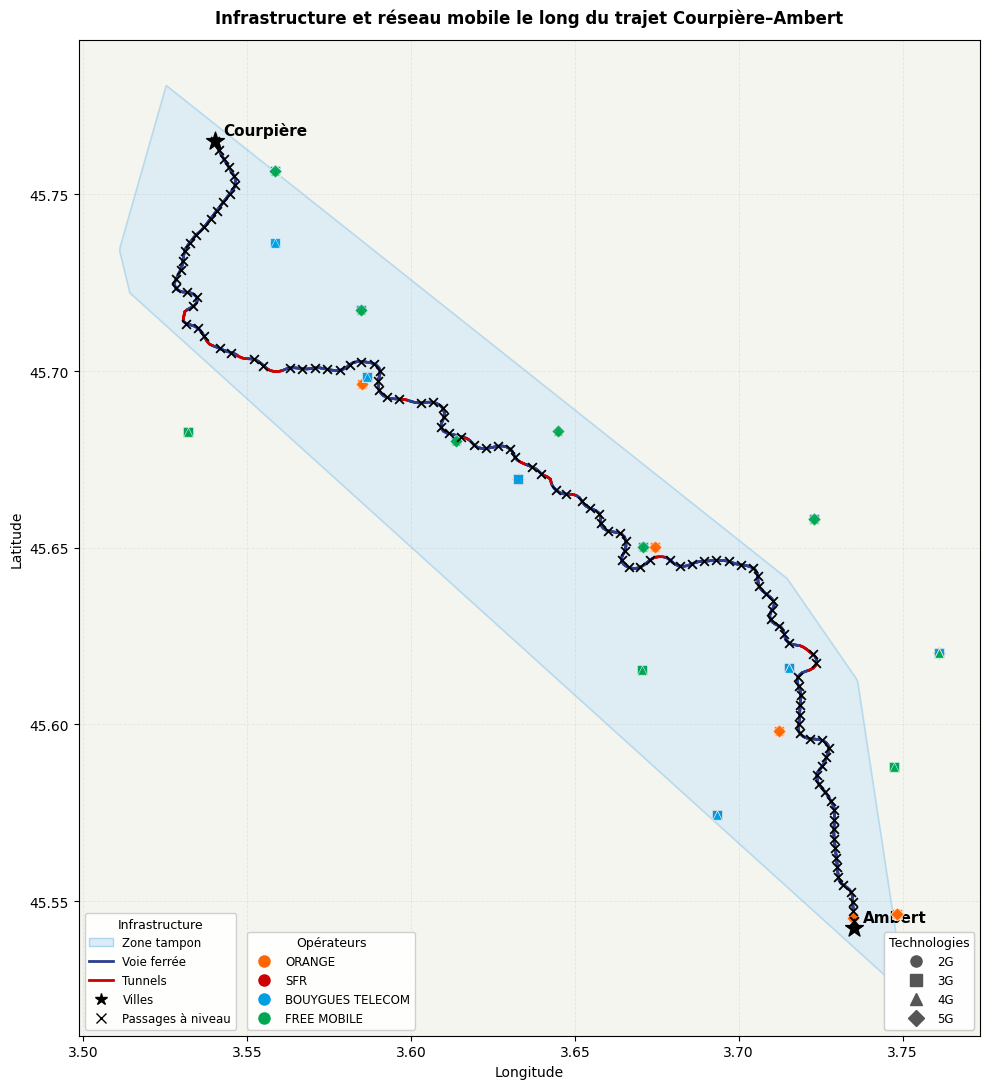

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CARTE — Infrastructure et réseau mobile — Ligne 785000 Courpière–Ambert
# ═══════════════════════════════════════════════════════════════════════════
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon

# ── 1. Tracé de la voie ferrée ──────────────────────────────────────────────
voie = df.groupby('point_id').agg(
    lat         = ('lat',          'first'),
    lon         = ('lon',          'first'),
    distance_km = ('distance_km',  'first'),
    in_tunnel   = ('in_tunnel',    'first'),
).reset_index().sort_values('distance_km')

# ── 2. Antennes ANFR — positions réelles (ant_lat / ant_lon) ────────────────
antennes = df.groupby(['ant_id', 'operateur', 'generation']).agg(
    ant_lat = ('ant_lat', 'first'),
    ant_lon = ('ant_lon', 'first'),
).reset_index().dropna(subset=['ant_lat', 'ant_lon'])

# ── 3. Palettes ──────────────────────────────────────────────────────────────
COLORS_OP = {
    'ORANGE':           '#FF6600',
    'SFR':              '#CC0000',
    'BOUYGUES TELECOM': '#009FE3',
    'FREE MOBILE':      '#00A651',
}
MARKERS_GEN = {'2G': 'o', '3G': 's', '4G': '^', '5G': 'D'}

# ── 4. Zone tampon (convex hull élargi autour de la voie) ────────────────────
coords = voie[['lon', 'lat']].values
center_lon, center_lat = coords[:, 0].mean(), coords[:, 1].mean()
expanded_coords = np.column_stack((
    center_lon + 1.15 * (coords[:, 0] - center_lon),
    center_lat + 1.15 * (coords[:, 1] - center_lat),
))
hull = ConvexHull(expanded_coords)
hull_pts = expanded_coords[hull.vertices]
hull_pts = np.vstack([hull_pts, hull_pts[0]])

# ── 5. Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 11))
ax.set_facecolor('#f5f5f0')

# Zone tampon
ax.add_patch(MplPolygon(
    hull_pts, closed=True,
    facecolor='#cce5f6', edgecolor='#90c8e8', linewidth=1.2,
    alpha=0.55, zorder=1,
))

# Voie ferrée (bleu = normal, rouge = tunnel)
for i in range(len(voie) - 1):
    r, r2 = voie.iloc[i], voie.iloc[i + 1]
    ax.plot([r['lon'], r2['lon']], [r['lat'], r2['lat']],
            color='#cc0000' if r['in_tunnel'] else '#2c3e8c',
            lw=1.8, zorder=3)

# Passages à niveau (1 point/15 hors tunnel)
pnx = voie[~voie['in_tunnel']].iloc[::15]
ax.scatter(pnx['lon'], pnx['lat'],
           marker='x', color='black', s=40, lw=1.3, zorder=5)

# Antennes ANFR aux vraies coordonnées
for op, color_op in COLORS_OP.items():
    for gen, marker in MARKERS_GEN.items():
        sub = antennes[(antennes['operateur'] == op) & (antennes['generation'] == gen)]
        if not sub.empty:
            ax.scatter(sub['ant_lon'], sub['ant_lat'],
                       marker=marker, color=color_op,
                       s=45, alpha=0.90, zorder=4,
                       linewidths=0.4, edgecolors='white')

# Villes
for ville, row in [('Courpière', voie.iloc[0]), ('Ambert', voie.iloc[-1])]:
    ax.scatter(row['lon'], row['lat'], marker='*', color='black', s=180, zorder=6)
    ax.annotate(ville, (row['lon'], row['lat']), textcoords='offset points',
                xytext=(6, 4), fontsize=11, fontweight='bold')

# ── 6. Légendes ──────────────────────────────────────────────────────────────
leg1 = ax.legend(handles=[
    mpatches.Patch(facecolor='#cce5f6', edgecolor='#90c8e8', label='Zone tampon', alpha=0.7),
    Line2D([0],[0], color='#2c3e8c', lw=2, label='Voie ferrée'),
    Line2D([0],[0], color='#cc0000', lw=2, label='Tunnels'),
    Line2D([0],[0], marker='*', color='black', linestyle='None', markersize=9, label='Villes'),
    Line2D([0],[0], marker='x', color='black', linestyle='None', markersize=7, label='Passages à niveau'),
], title='Infrastructure', loc='lower left', fontsize=8.5, title_fontsize=9, framealpha=0.92)
ax.add_artist(leg1)

leg2 = ax.legend(handles=[
    Line2D([0],[0], marker='o', color=c, linestyle='None', markersize=8, label=op)
    for op, c in COLORS_OP.items()
], title='Opérateurs', loc='lower center', fontsize=8.5, title_fontsize=9,
   framealpha=0.92, bbox_to_anchor=(0.28, 0.0))
ax.add_artist(leg2)

leg3 = ax.legend(handles=[
    Line2D([0],[0], marker=m, color='#555555', linestyle='None', markersize=8, label=gen)
    for gen, m in MARKERS_GEN.items()
], title='Technologies', loc='lower right', fontsize=8.5, title_fontsize=9, framealpha=0.92)
ax.add_artist(leg3)

# ── 7. Mise en page ───────────────────────────────────────────────────────────
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude',  fontsize=10)
ax.set_title('Infrastructure et réseau mobile le long du trajet Courpière–Ambert',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
plt.tight_layout()
plt.savefig('carte_reseau_mobile_ligne785000.png', dpi=180, bbox_inches='tight')
plt.show()

Saved


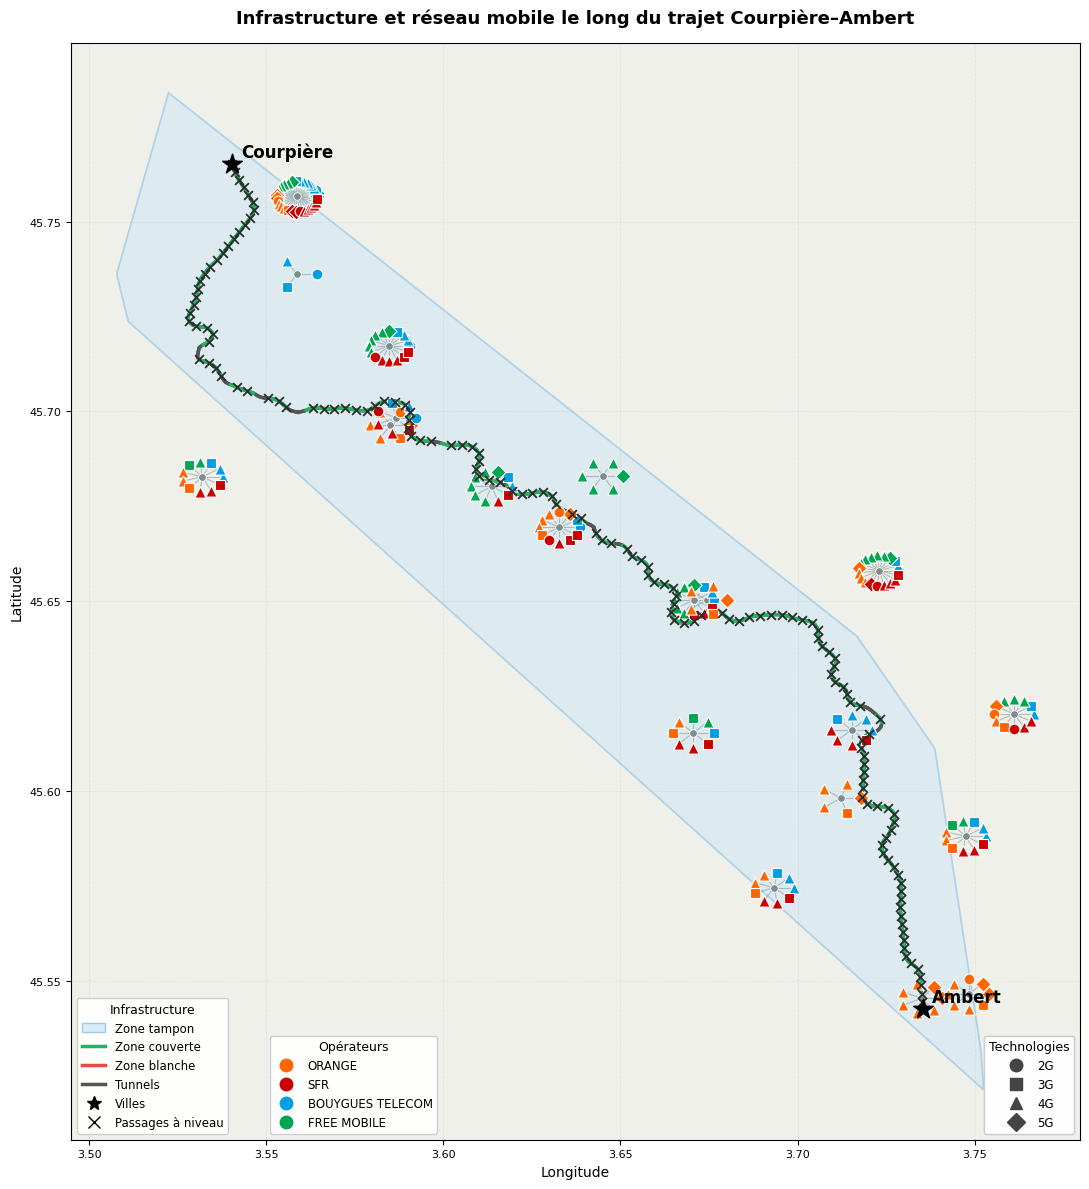

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon, FancyArrowPatch
from scipy.spatial import ConvexHull


# ── 1. Voie ferrée ────────────────────────────────────────────────────────────
voie = df.groupby('point_id').agg(
    lat=('lat','first'), lon=('lon','first'),
    distance_km=('distance_km','first'), in_tunnel=('in_tunnel','first'),
    zone_blanche=('zone_blanche','first'),
).reset_index().sort_values('distance_km')

# ── 2. Antennes ANFR ──────────────────────────────────────────────────────────
antennes = df.groupby('ant_id').agg(
    ant_lat=('ant_lat','first'), ant_lon=('ant_lon','first'),
    operateur=('operateur','first'), generation=('generation','first'),
).reset_index().dropna(subset=['ant_lat','ant_lon'])

# Grouper par position physique (support)
antennes['pos_key'] = antennes['ant_lat'].round(3).astype(str) + '_' + antennes['ant_lon'].round(3).astype(str)

# ── 3. Palettes ───────────────────────────────────────────────────────────────
COLORS_OP = {
    'ORANGE':           '#FF6600',
    'SFR':              '#CC0000',
    'BOUYGUES TELECOM': '#009FE3',
    'FREE MOBILE':      '#00A651',
}
MARKERS_GEN = {'2G': 'o', '3G': 's', '4G': '^', '5G': 'D'}
SIZES_GEN   = {'2G': 60,  '3G': 60,  '4G': 65,  '5G': 60}

# ── 4. Zone tampon ────────────────────────────────────────────────────────────
coords = voie[['lon','lat']].values
cx, cy = coords[:,0].mean(), coords[:,1].mean()
exp = np.column_stack((cx + 1.18*(coords[:,0]-cx), cy + 1.18*(coords[:,1]-cy)))
hull = ConvexHull(exp)
hull_pts = exp[hull.vertices]
hull_pts = np.vstack([hull_pts, hull_pts[0]])

# ── 5. Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 12))
ax.set_facecolor('#f0f0eb')
fig.patch.set_facecolor('white')

# Zone tampon
ax.add_patch(MplPolygon(hull_pts, closed=True,
    facecolor='#cce5f6', edgecolor='#7ab8e0', lw=1.3, alpha=0.5, zorder=1))

# ── Voie ferrée colorée zone_blanche (rouge) / couverte (vert) ───────────────
for i in range(len(voie) - 1):
    r, r2 = voie.iloc[i], voie.iloc[i+1]
    if r['in_tunnel']:
        color = '#555555'   # tunnel → gris
    elif r['zone_blanche'] == 1:
        color = '#e74c3c'   # zone blanche → rouge
    else:
        color = '#27ae60'   # couverte → vert
    ax.plot([r['lon'], r2['lon']], [r['lat'], r2['lat']],
            color=color, lw=2.5, zorder=3, solid_capstyle='round')

# ── Antennes : système radial par support ─────────────────────────────────────
R_ORBIT = 0.004   # rayon orbite en degrés (~400m)

for pos_key, group in antennes.groupby('pos_key'):
    center_lon = group['ant_lon'].iloc[0]
    center_lat = group['ant_lat'].iloc[0]
    n = len(group)

    if n == 1:
        row = group.iloc[0]
        ax.scatter(center_lon, center_lat,
                   marker=MARKERS_GEN.get(row['generation'], 'o'),
                   color=COLORS_OP.get(row['operateur'], 'gray'),
                   s=SIZES_GEN.get(row['generation'], 55),
                   zorder=6, edgecolors='white', linewidths=0.8)
    else:
        # Point central gris (support physique)
        ax.scatter(center_lon, center_lat,
                   marker='o', color='#7f8c8d', s=30, zorder=5,
                   edgecolors='white', linewidths=0.6)
        # Placer chaque antenne en orbite autour du support
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        # Correction aspect ratio lat/lon
        aspect = np.cos(np.radians(center_lat))
        for idx, (_, row) in enumerate(group.iterrows()):
            orb_lon = center_lon + R_ORBIT * np.cos(angles[idx]) / aspect
            orb_lat = center_lat + R_ORBIT * np.sin(angles[idx])
            # Ligne du centre vers l'antenne
            ax.plot([center_lon, orb_lon], [center_lat, orb_lat],
                    color='#95a5a6', lw=0.8, zorder=4, alpha=0.7)
            # Marker antenne
            ax.scatter(orb_lon, orb_lat,
                       marker=MARKERS_GEN.get(row['generation'], 'o'),
                       color=COLORS_OP.get(row['operateur'], 'gray'),
                       s=SIZES_GEN.get(row['generation'], 55),
                       zorder=6, edgecolors='white', linewidths=0.8)

# ── Villes ────────────────────────────────────────────────────────────────────
for ville, row in [('Courpière', voie.iloc[0]), ('Ambert', voie.iloc[-1])]:
    ax.scatter(row['lon'], row['lat'], marker='*', color='black', s=220, zorder=8)
    ax.annotate(ville, (row['lon'], row['lat']), textcoords='offset points',
                xytext=(7, 5), fontsize=12, fontweight='bold', color='black',
                zorder=9)

# ── Passages à niveau (approximation) ────────────────────────────────────────
pnx = voie[~voie['in_tunnel']].iloc[::12]
ax.scatter(pnx['lon'], pnx['lat'], marker='x', color='#2c2c2c',
           s=40, lw=1.3, zorder=7)

# ── Légendes ──────────────────────────────────────────────────────────────────
leg1 = ax.legend(handles=[
    mpatches.Patch(facecolor='#cce5f6', edgecolor='#7ab8e0', label='Zone tampon', alpha=0.7),
    Line2D([0],[0], color='#27ae60', lw=2.5, label='Zone couverte'),
    Line2D([0],[0], color='#e74c3c', lw=2.5, label='Zone blanche'),
    Line2D([0],[0], color='#555555', lw=2.5, label='Tunnels'),
    Line2D([0],[0], marker='*', color='black', linestyle='None', markersize=10, label='Villes'),
    Line2D([0],[0], marker='x', color='black', linestyle='None', markersize=8, label='Passages à niveau'),
], title='Infrastructure', loc='lower left', fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg1)

leg2 = ax.legend(handles=[
    Line2D([0],[0], marker='o', color=c, linestyle='None', markersize=9, label=op)
    for op, c in COLORS_OP.items()
], title='Opérateurs', loc='lower center', fontsize=8.5, title_fontsize=9,
   framealpha=0.95, bbox_to_anchor=(0.28, 0.0))
ax.add_artist(leg2)

leg3 = ax.legend(handles=[
    Line2D([0],[0], marker=m, color='#444444', linestyle='None', markersize=9, label=gen)
    for gen, m in MARKERS_GEN.items()
], title='Technologies', loc='lower right', fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg3)

# ── Mise en page ──────────────────────────────────────────────────────────────
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude',  fontsize=10)
ax.set_title('Infrastructure et réseau mobile le long du trajet Courpière–Ambert',
             fontsize=13, fontweight='bold', pad=14)
ax.grid(True, alpha=0.22, linestyle='--', lw=0.6)
ax.tick_params(labelsize=8)
plt.tight_layout()
print("Saved")
plt.show()

### Diagrammes séparés par génération — tronçon Courpière–Ambert couvert

Pour chaque technologie (2G, 3G, 4G, 5G), un diagramme dédié montre le débit le long
de la ligne, le seuil de couverture (ligne rouge), et surligne en couleur le(s)
tronçon(s) **réellement couverts** entre Courpière (km 0) et Ambert (km 30).


In [14]:
DIST_MIN = pivot_debit['distance_km'].min()
DIST_MAX = pivot_debit['distance_km'].max()
GAP_MAX_KM = 0.1   # au-delà de cet écart entre deux points couverts, on coupe le tronçon

def get_troncons(pivot_debit, gen, seuil, gap_max=GAP_MAX_KM):
    """Retourne la liste des tronçons contigus couverts : [(km_debut, km_fin, debit_moyen), ...]"""
    mask = (pivot_debit[gen] >= seuil) & (~pivot_debit['in_tunnel'])
    sub = pivot_debit.loc[mask, ['distance_km', gen]].sort_values('distance_km').reset_index(drop=True)
    if sub.empty:
        return []

    troncons = []
    start_idx = 0
    for i in range(1, len(sub)):
        if sub.loc[i, 'distance_km'] - sub.loc[i-1, 'distance_km'] > gap_max:
            seg = sub.iloc[start_idx:i]
            troncons.append((seg['distance_km'].iloc[0], seg['distance_km'].iloc[-1], seg[gen].mean()))
            start_idx = i
    seg = sub.iloc[start_idx:]
    troncons.append((seg['distance_km'].iloc[0], seg['distance_km'].iloc[-1], seg[gen].mean()))
    return troncons

def plot_couverture_generation(pivot_debit, gen, color, seuil=SEUIL_DEBIT_MBPS):
    """Diagramme dédié : débit le long de la ligne + tronçon(s) couvert(s) annotés (km début→fin, débit moyen)."""
    fig, ax = plt.subplots(figsize=(16, 4.2))

    if gen not in pivot_debit.columns:
        ax.text(0.5, 0.5, f'{gen} — pas de données', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        return

    mask_tunnel = pivot_debit['in_tunnel']
    mask_ok     = (~mask_tunnel) & (pivot_debit[gen] >= seuil)
    mask_nok    = (~mask_tunnel) & (pivot_debit[gen] < seuil)

    troncons = get_troncons(pivot_debit, gen, seuil)

    # Bande de fond colorée = tronçon(s) couvert(s)
    for (a, b, _) in troncons:
        ax.axvspan(a, b, color=color, alpha=0.15, zorder=0)

    # Courbe de débit
    ax.plot(pivot_debit['distance_km'], pivot_debit[gen],
            color=color, lw=1.6, zorder=3)
    ax.fill_between(pivot_debit.loc[mask_ok, 'distance_km'],
                    pivot_debit.loc[mask_ok, gen],
                    color=color, alpha=0.35, zorder=2)

    # Points non couverts au sol
    if mask_nok.any():
        ax.scatter(pivot_debit.loc[mask_nok, 'distance_km'], [0]*mask_nok.sum(),
                   color='lightgray', s=6, zorder=2)

    # Tunnels
    for _, row in pivot_debit[mask_tunnel].iterrows():
        ax.axvspan(row['distance_km'] - 0.01, row['distance_km'] + 0.01,
                   color='black', alpha=0.2, zorder=1)

    ax.axhline(seuil, color='red', lw=1.3, ls='--', alpha=0.8,
               label=f'Seuil = {seuil} Mbps')

    # Annotation directe sur le graphique pour chaque tronçon : km début→fin + débit moyen
    y_top = pivot_debit[gen].max() * 1.08 if pivot_debit[gen].max() > 0 else 1
    for (a, b, debit_moy) in troncons:
        mid = (a + b) / 2
        ax.annotate(f'km {a:.2f} → km {b:.2f}\n{debit_moy:.1f} Mbps moy.',
                    xy=(mid, y_top), ha='center', va='bottom', fontsize=9,
                    color=color, fontweight='bold')
        ax.plot([a, b], [y_top*0.97, y_top*0.97], color=color, lw=2, solid_capstyle='butt')

    n_couv = mask_ok.sum()
    pct_couv = n_couv / len(pivot_debit) * 100
    km_couv = n_couv * (DIST_MAX - DIST_MIN) / len(pivot_debit)
    debit_moy_global = pivot_debit.loc[mask_ok, gen].mean() if mask_ok.any() else 0

    ax.set_xlim(DIST_MIN, DIST_MAX)
    ax.set_ylim(0, y_top * 1.25)
    ax.set_xlabel('Distance depuis Courpière (km)', fontsize=11)
    ax.set_ylabel('Débit (Mbps)', fontsize=11)
    ax.set_title(f'{gen} — Courpière → Ambert  |  couvert : {pct_couv:.1f}% de la ligne (≈ {km_couv:.1f} km)  |  débit moyen global : {debit_moy_global:.1f} Mbps',
                 fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'couverture_{gen}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"{gen} — tronçons couverts (seuil {seuil} Mbps) :")
    if not troncons:
        print("   Aucun tronçon couvert.")
    for (a, b, debit_moy) in troncons:
        print(f"   km {a:6.2f} → km {b:6.2f}  ({b-a:5.2f} km)  |  débit moyen : {debit_moy:6.1f} Mbps")
    print(f"Sauvegardé : couverture_{gen}.png\n")


#### Couverture 2G


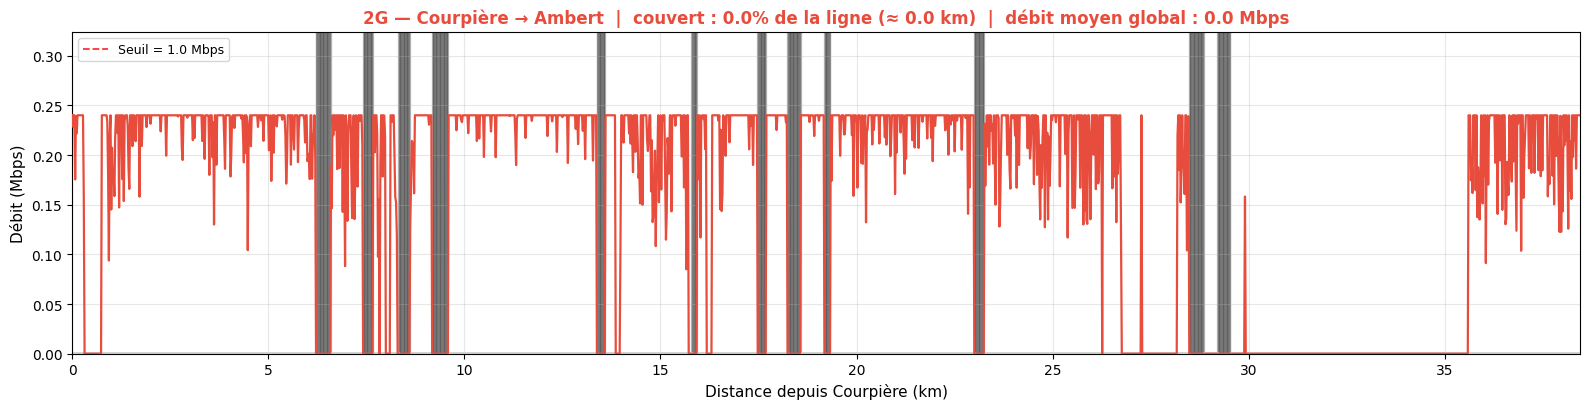

2G — tronçons couverts (seuil 1.0 Mbps) :
   Aucun tronçon couvert.
Sauvegardé : couverture_2G.png



In [15]:
plot_couverture_generation(pivot_debit, '2G', COLORS_GEN['2G'])


#### Couverture 3G


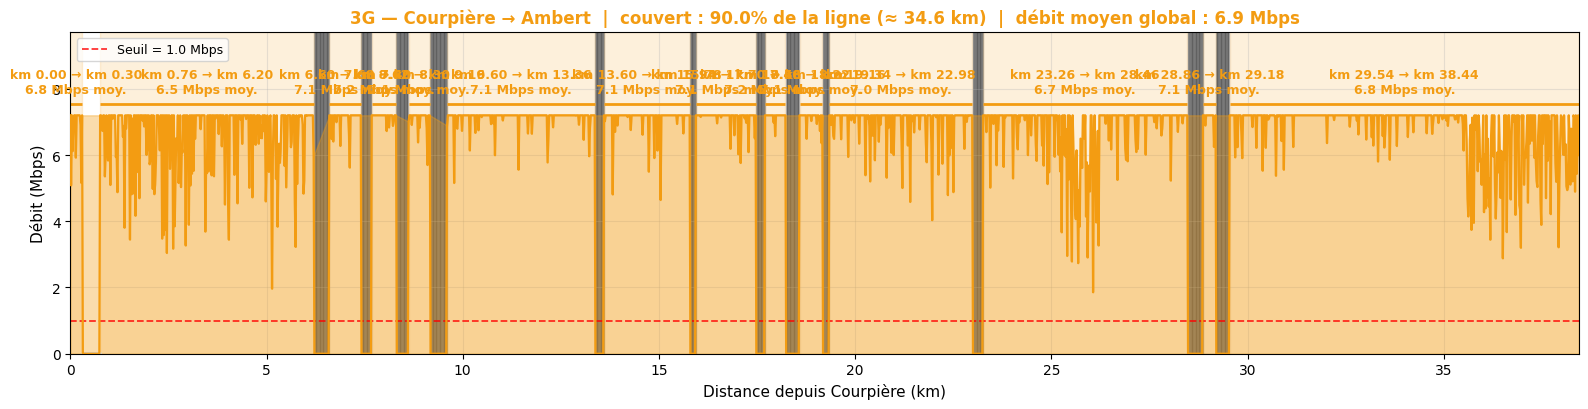

3G — tronçons couverts (seuil 1.0 Mbps) :
   km   0.00 → km   0.30  ( 0.30 km)  |  débit moyen :    6.8 Mbps
   km   0.76 → km   6.20  ( 5.44 km)  |  débit moyen :    6.5 Mbps
   km   6.60 → km   7.40  ( 0.80 km)  |  débit moyen :    7.1 Mbps
   km   7.68 → km   8.30  ( 0.62 km)  |  débit moyen :    7.2 Mbps
   km   8.62 → km   9.16  ( 0.54 km)  |  débit moyen :    7.1 Mbps
   km   9.60 → km  13.36  ( 3.76 km)  |  débit moyen :    7.1 Mbps
   km  13.60 → km  15.78  ( 2.18 km)  |  débit moyen :    7.1 Mbps
   km  15.94 → km  17.46  ( 1.52 km)  |  débit moyen :    7.1 Mbps
   km  17.70 → km  18.22  ( 0.52 km)  |  débit moyen :    7.2 Mbps
   km  18.58 → km  19.16  ( 0.58 km)  |  débit moyen :    7.1 Mbps
   km  19.34 → km  22.98  ( 3.64 km)  |  débit moyen :    7.0 Mbps
   km  23.26 → km  28.46  ( 5.20 km)  |  débit moyen :    6.7 Mbps
   km  28.86 → km  29.18  ( 0.32 km)  |  débit moyen :    7.1 Mbps
   km  29.54 → km  38.44  ( 8.90 km)  |  débit moyen :    6.8 Mbps
Sauvegardé : couvert

In [16]:
plot_couverture_generation(pivot_debit, '3G', COLORS_GEN['3G'])


#### Couverture 4G


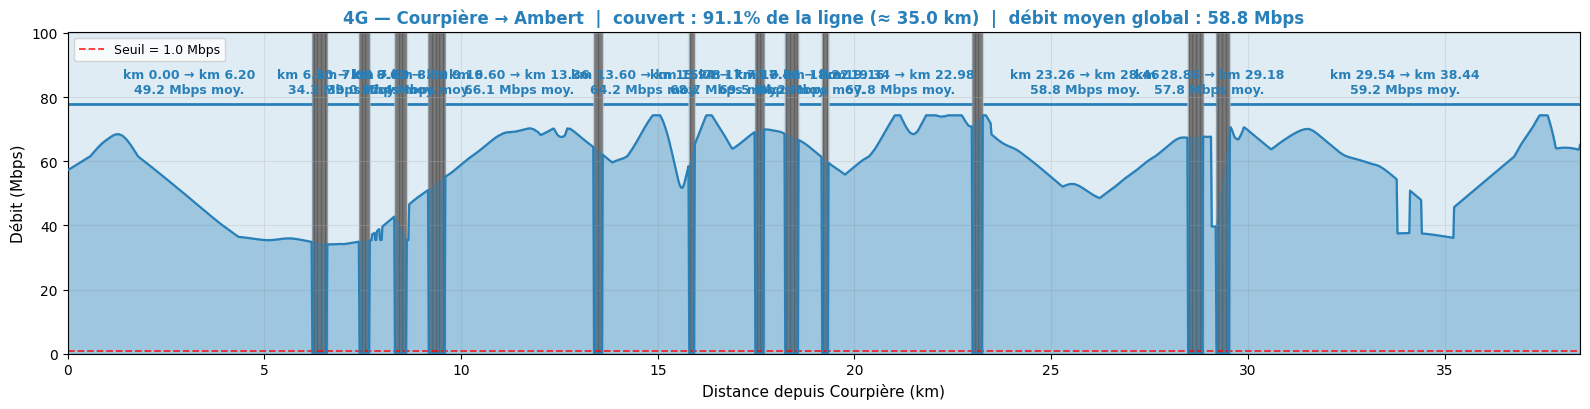

4G — tronçons couverts (seuil 1.0 Mbps) :
   km   0.00 → km   6.20  ( 6.20 km)  |  débit moyen :   49.2 Mbps
   km   6.60 → km   7.40  ( 0.80 km)  |  débit moyen :   34.3 Mbps
   km   7.68 → km   8.30  ( 0.62 km)  |  débit moyen :   39.0 Mbps
   km   8.62 → km   9.16  ( 0.54 km)  |  débit moyen :   47.4 Mbps
   km   9.60 → km  13.36  ( 3.76 km)  |  débit moyen :   66.1 Mbps
   km  13.60 → km  15.78  ( 2.18 km)  |  débit moyen :   64.2 Mbps
   km  15.94 → km  17.46  ( 1.52 km)  |  débit moyen :   68.7 Mbps
   km  17.70 → km  18.22  ( 0.52 km)  |  débit moyen :   69.5 Mbps
   km  18.58 → km  19.16  ( 0.58 km)  |  débit moyen :   64.2 Mbps
   km  19.34 → km  22.98  ( 3.64 km)  |  débit moyen :   67.8 Mbps
   km  23.26 → km  28.46  ( 5.20 km)  |  débit moyen :   58.8 Mbps
   km  28.86 → km  29.18  ( 0.32 km)  |  débit moyen :   57.8 Mbps
   km  29.54 → km  38.44  ( 8.90 km)  |  débit moyen :   59.2 Mbps
Sauvegardé : couverture_4G.png



In [17]:
plot_couverture_generation(pivot_debit, '4G', COLORS_GEN['4G'])


#### Couverture 5G


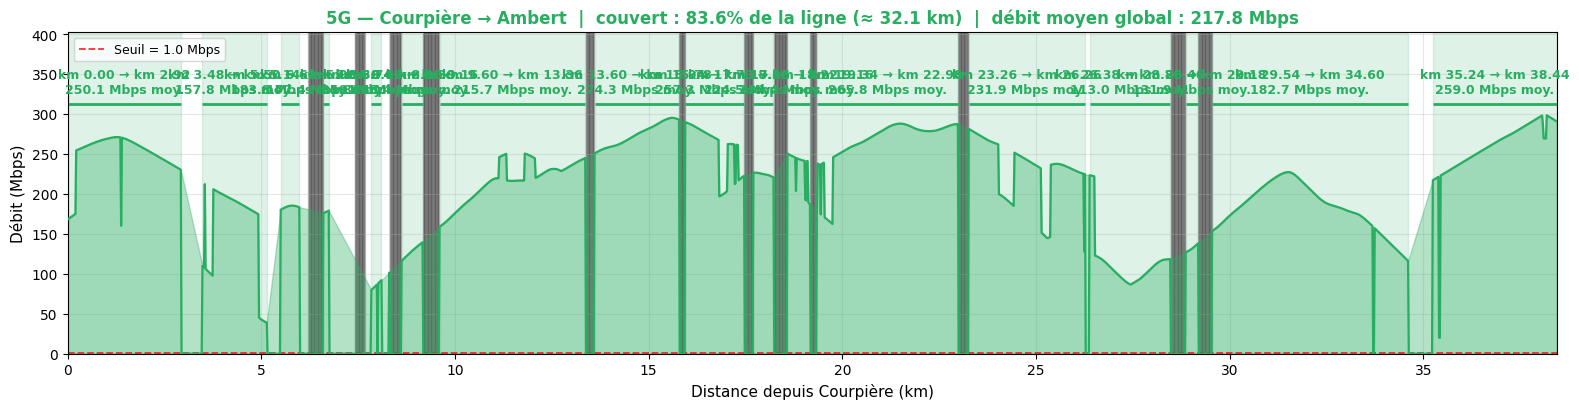

5G — tronçons couverts (seuil 1.0 Mbps) :
   km   0.00 → km   2.92  ( 2.92 km)  |  débit moyen :  250.1 Mbps
   km   3.48 → km   5.14  ( 1.66 km)  |  débit moyen :  157.8 Mbps
   km   5.50 → km   5.98  ( 0.48 km)  |  débit moyen :  183.8 Mbps
   km   6.60 → km   6.74  ( 0.14 km)  |  débit moyen :  177.4 Mbps
   km   7.84 → km   8.10  ( 0.26 km)  |  débit moyen :   85.8 Mbps
   km   8.30 → km   8.30  ( 0.00 km)  |  débit moyen :  101.5 Mbps
   km   8.62 → km   9.16  ( 0.54 km)  |  débit moyen :  128.4 Mbps
   km   9.60 → km  13.36  ( 3.76 km)  |  débit moyen :  215.7 Mbps
   km  13.60 → km  15.78  ( 2.18 km)  |  débit moyen :  274.3 Mbps
   km  15.94 → km  17.46  ( 1.52 km)  |  débit moyen :  257.3 Mbps
   km  17.70 → km  18.22  ( 0.52 km)  |  débit moyen :  224.5 Mbps
   km  18.58 → km  19.16  ( 0.58 km)  |  débit moyen :  234.4 Mbps
   km  19.34 → km  22.98  ( 3.64 km)  |  débit moyen :  265.8 Mbps
   km  23.26 → km  26.26  ( 3.00 km)  |  débit moyen :  231.9 Mbps
   km  26.38 → km  2

In [18]:
plot_couverture_generation(pivot_debit, '5G', COLORS_GEN['5G'])


### Diagrammes altitude/distance par génération — couverture le long du relief

Même tracé que la carte "meilleure technologie" (altitude du terrain en fonction de la
distance), mais ici **un graphique par génération** : chaque point du trajet est colorié
selon que cette génération spécifique le couvre (≥ seuil) ou non, sans comparer aux autres
générations. Cela permet de voir si la couverture d'une techno suit un profil de terrain
particulier (ex. perdue en altitude, ou dans les creux).


In [19]:
def plot_altitude_generation(pivot_debit, gen, color, seuil=SEUIL_DEBIT_MBPS):
    """Trace altitude (m) vs distance (km), point couvert en couleur / non couvert en gris."""
    fig, ax = plt.subplots(figsize=(16, 3.5))

    if gen not in pivot_debit.columns:
        ax.text(0.5, 0.5, f'{gen} — pas de données', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        return

    mask_tunnel = pivot_debit['in_tunnel']
    mask_ok     = (~mask_tunnel) & (pivot_debit[gen] >= seuil)
    mask_nok    = (~mask_tunnel) & (pivot_debit[gen] < seuil)

    ax.scatter(pivot_debit.loc[mask_ok, 'distance_km'],
               pivot_debit.loc[mask_ok, 'altitude_m'],
               c=color, s=14, alpha=0.9, label=f'{gen} couvert (≥ {seuil} Mbps)', zorder=3)
    ax.scatter(pivot_debit.loc[mask_nok, 'distance_km'],
               pivot_debit.loc[mask_nok, 'altitude_m'],
               c='lightgray', s=14, alpha=0.8, label='Non couvert', zorder=2)
    ax.scatter(pivot_debit.loc[mask_tunnel, 'distance_km'],
               pivot_debit.loc[mask_tunnel, 'altitude_m'],
               c='black', s=14, alpha=0.9, label='Tunnel', zorder=4)

    n_couv = mask_ok.sum()
    pct_couv = n_couv / len(pivot_debit) * 100

    ax.set_xlabel('Distance depuis Courpière (km)', fontsize=11)
    ax.set_ylabel('Altitude (m)', fontsize=11)
    ax.set_title(f'{gen} — Couverture le long du relief — Courpière → Ambert  |  couvert : {pct_couv:.1f}% de la ligne',
                 fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'altitude_{gen}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sauvegardé : altitude_{gen}.png\n")


#### Couverture 2G — vue altitude/relief


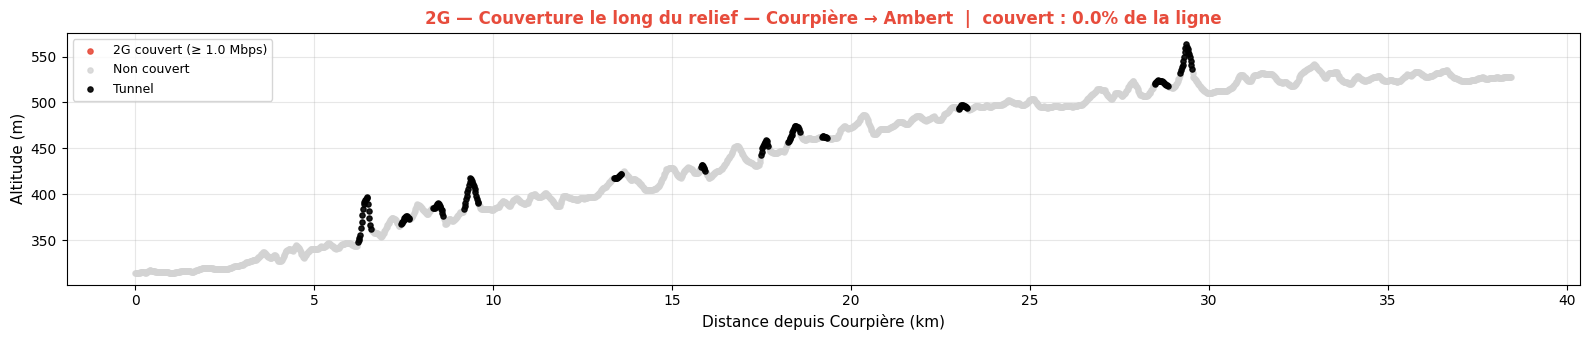

Sauvegardé : altitude_2G.png



In [20]:
plot_altitude_generation(pivot_debit, '2G', COLORS_GEN['2G'])


#### Couverture 3G — vue altitude/relief


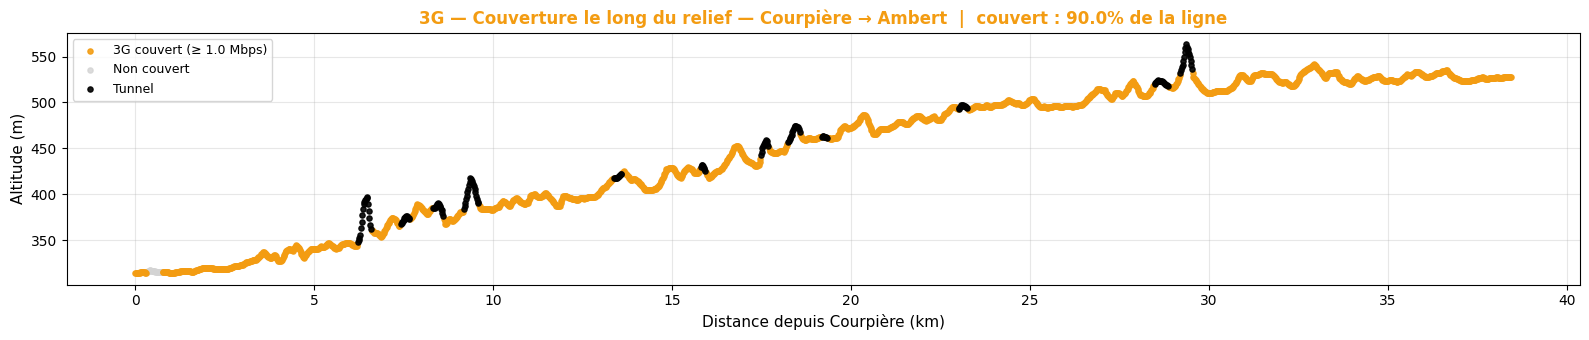

Sauvegardé : altitude_3G.png



In [21]:
plot_altitude_generation(pivot_debit, '3G', COLORS_GEN['3G'])


#### Couverture 4G — vue altitude/relief


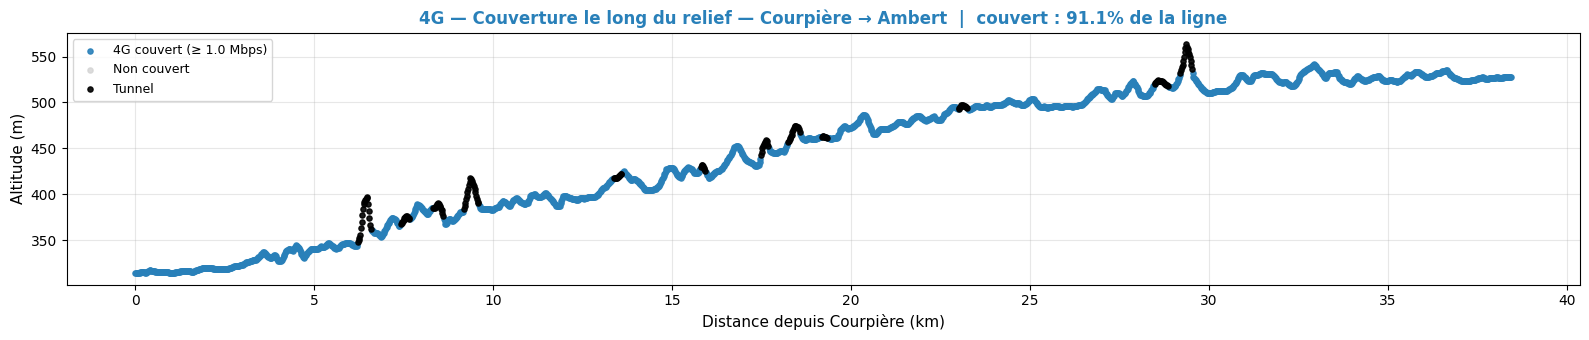

Sauvegardé : altitude_4G.png



In [22]:
plot_altitude_generation(pivot_debit, '4G', COLORS_GEN['4G'])


#### Couverture 5G — vue altitude/relief


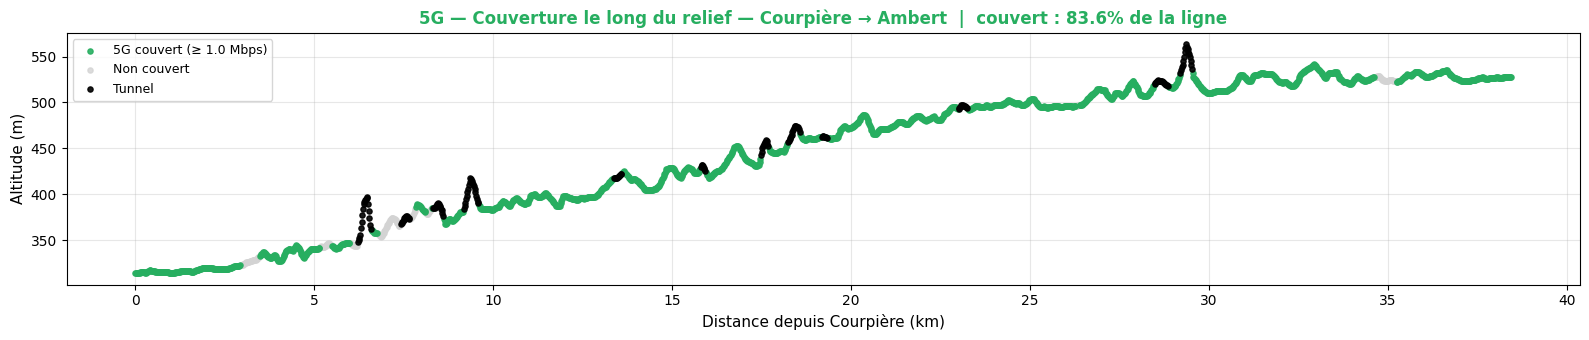

Sauvegardé : altitude_5G.png



In [23]:
plot_altitude_generation(pivot_debit, '5G', COLORS_GEN['5G'])


---
### Diagrammes de couverture combinée débit + latence

Au-delà du seuil débit seul (`SEUIL_DEBIT_MBPS`), on ajoute une condition de **latence**
(`rtt_ms`, le round-trip-time du pipeline — équivalent de la latence applicative).

Un point est considéré couvert pour une génération donnée si, **simultanément** :
- `debit_adj_mbps ≥ SEUIL_DEBIT_MBPS` (même seuil que la zone blanche, pour rester
  cohérent avec la Partie 1 — un seuil unique permet de comparer les générations entre
  elles sur un pied d'égalité, plutôt que des seuils différenciés par techno qui mesurent
  une notion différente : la qualité de service propre à chaque génération, cf. `qualite_ok`
  dans `enrich_data.py`) ;
- `rtt_ms < SEUIL_LATENCE_MS`.

Trois seuils de latence sont testés indépendamment (3 diagrammes séparés par seuil) :
**10 ms** (usage temps réel strict — sécurité ferroviaire, contrôle-commande),
**50 ms** (usage interactif standard — supervision, vidéo temps réel dégradée),
**100 ms** (usage tolérant — télémétrie, messagerie).

Le critère combiné (et non la latence seule) est utilisé : un lien à faible latence mais à
débit insuffisant n'est pas exploitable pour les fonctions critiques visées par FerroMobile,
donc l'isoler sans condition de débit n'aurait pas de sens opérationnel ici.

In [24]:
# Pivot RTT par génération (même structure que pivot_debit)
gen_rtt = df.groupby(['point_id', 'generation']).agg(
    best_debit = ('debit_adj_mbps', 'max'),
    best_rtt   = ('rtt_ms',         'min'),   # meilleur cas = latence la plus faible disponible
).reset_index()

pivot_rtt = gen_rtt.pivot_table(
    index='point_id', columns='generation', values='best_rtt', aggfunc='min'
)
pivot_rtt.columns = [f'{c}_rtt' for c in pivot_rtt.columns]

pivot_debit_rtt = pivot_debit.merge(pivot_rtt, on='point_id', how='left')

print("Aperçu colonnes RTT disponibles :", [c for c in pivot_debit_rtt.columns if c.endswith('_rtt')])
print(f"\nValeurs manquantes RTT (pas de mesure dispo, ex. tunnel) :")
for gen in ['2G','3G','4G','5G']:
    col = f'{gen}_rtt'
    if col in pivot_debit_rtt.columns:
        print(f"  {gen} : {pivot_debit_rtt[col].isna().sum()} points sans RTT mesuré")


Aperçu colonnes RTT disponibles : ['2G_rtt', '3G_rtt', '4G_rtt', '5G_rtt']

Valeurs manquantes RTT (pas de mesure dispo, ex. tunnel) :
  2G : 608 points sans RTT mesuré
  3G : 193 points sans RTT mesuré
  4G : 171 points sans RTT mesuré
  5G : 315 points sans RTT mesuré


In [25]:
def get_troncons_latence(pivot_debit_rtt, gen, seuil_debit, seuil_latence_ms, gap_max=GAP_MAX_KM):
    """Tronçons couverts : débit ≥ seuil_debit ET rtt_ms < seuil_latence_ms, hors tunnel."""
    rtt_col = f'{gen}_rtt'
    if gen not in pivot_debit_rtt.columns or rtt_col not in pivot_debit_rtt.columns:
        return []
    mask = (
        (pivot_debit_rtt[gen] >= seuil_debit) &
        (pivot_debit_rtt[rtt_col].notna()) &
        (pivot_debit_rtt[rtt_col] < seuil_latence_ms) &
        (~pivot_debit_rtt['in_tunnel'])
    )
    sub = pivot_debit_rtt.loc[mask, ['distance_km']].sort_values('distance_km').reset_index(drop=True)
    if sub.empty:
        return []
    troncons, start, prev = [], sub['distance_km'].iloc[0], sub['distance_km'].iloc[0]
    for d in sub['distance_km'].iloc[1:]:
        if d - prev > gap_max:
            troncons.append((start, prev))
            start = d
        prev = d
    troncons.append((start, prev))
    return troncons


def plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms, seuil_debit=SEUIL_DEBIT_MBPS):
    """Une carte par seuil de latence : tronçons couverts (débit ET latence) par génération."""
    fig, ax = plt.subplots(figsize=(16, 4))

    y_positions = {'2G': 0, '3G': 1, '4G': 2, '5G': 3}
    for gen, y in y_positions.items():
        troncons = get_troncons_latence(pivot_debit_rtt, gen, seuil_debit, seuil_latence_ms)
        for (a, b) in troncons:
            width = max(b - a, 0.05)
            ax.barh(y, width, left=a, height=0.7, color=COLORS_GEN[gen],
                    edgecolor='white', linewidth=0.5, zorder=2)
        n_pts = sum(1 for _ in troncons)

    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_xlabel('Distance depuis Courpière (km)', fontsize=12)
    ax.set_title(
        f'Couverture combinée débit ≥ {seuil_debit} Mbps ET latence < {seuil_latence_ms} ms — par génération',
        fontsize=13, fontweight='bold')
    ax.set_xlim(DIST_MIN, DIST_MAX)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    fname = f'couverture_latence_{seuil_latence_ms}ms.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sauvegardé : {fname}\n")

    print(f"Couverture par génération (débit ≥ {seuil_debit} Mbps ET rtt < {seuil_latence_ms} ms) :")
    for gen in ['2G','3G','4G','5G']:
        rtt_col = f'{gen}_rtt'
        if gen in pivot_debit_rtt.columns and rtt_col in pivot_debit_rtt.columns:
            mask = (
                (pivot_debit_rtt[gen] >= seuil_debit) &
                (pivot_debit_rtt[rtt_col].notna()) &
                (pivot_debit_rtt[rtt_col] < seuil_latence_ms) &
                (~pivot_debit_rtt['in_tunnel'])
            )
            n = mask.sum()
            pct = n / len(pivot_debit_rtt) * 100
            print(f"  {gen} : {n:4d} points ({pct:5.1f}% de la ligne)")


#### Couverture combinée — seuil latence < 10 ms (temps réel strict)

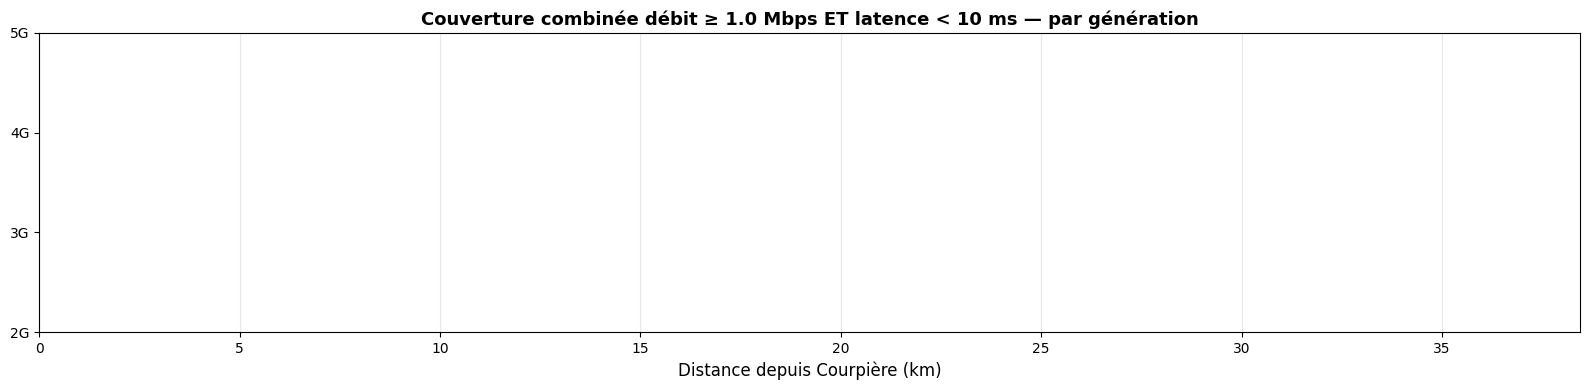

Sauvegardé : couverture_latence_10ms.png

Couverture par génération (débit ≥ 1.0 Mbps ET rtt < 10 ms) :
  2G :    0 points (  0.0% de la ligne)
  3G :    0 points (  0.0% de la ligne)
  4G :    0 points (  0.0% de la ligne)
  5G :    0 points (  0.0% de la ligne)


In [26]:
plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms=10)

#### Couverture combinée — seuil latence < 50 ms (interactif standard)

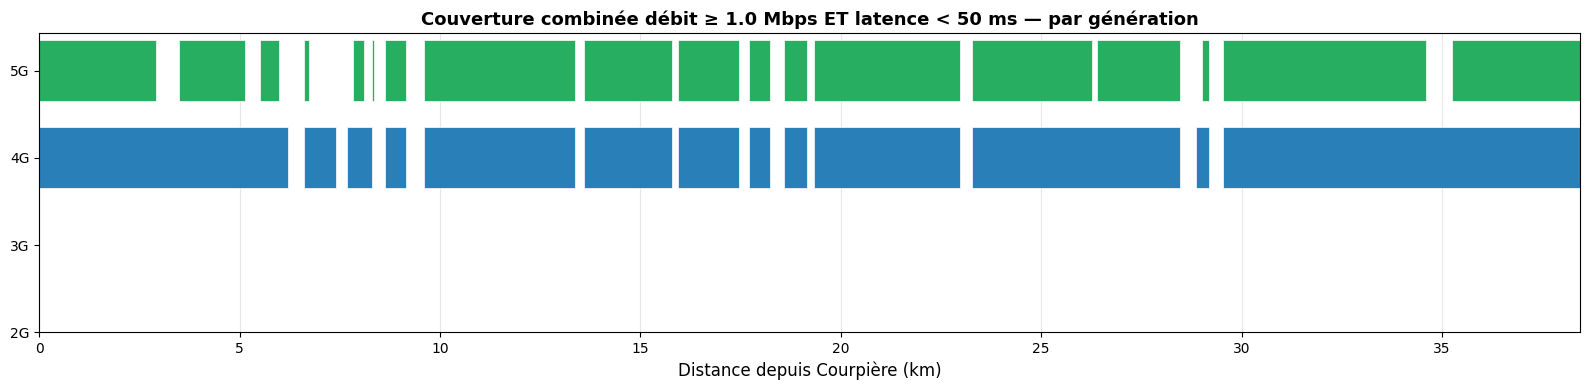

Sauvegardé : couverture_latence_50ms.png

Couverture par génération (débit ≥ 1.0 Mbps ET rtt < 50 ms) :
  2G :    0 points (  0.0% de la ligne)
  3G :    0 points (  0.0% de la ligne)
  4G : 1752 points ( 91.1% de la ligne)
  5G : 1601 points ( 83.3% de la ligne)


In [27]:
plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms=50)

#### Couverture combinée — seuil latence < 100 ms (tolérant)

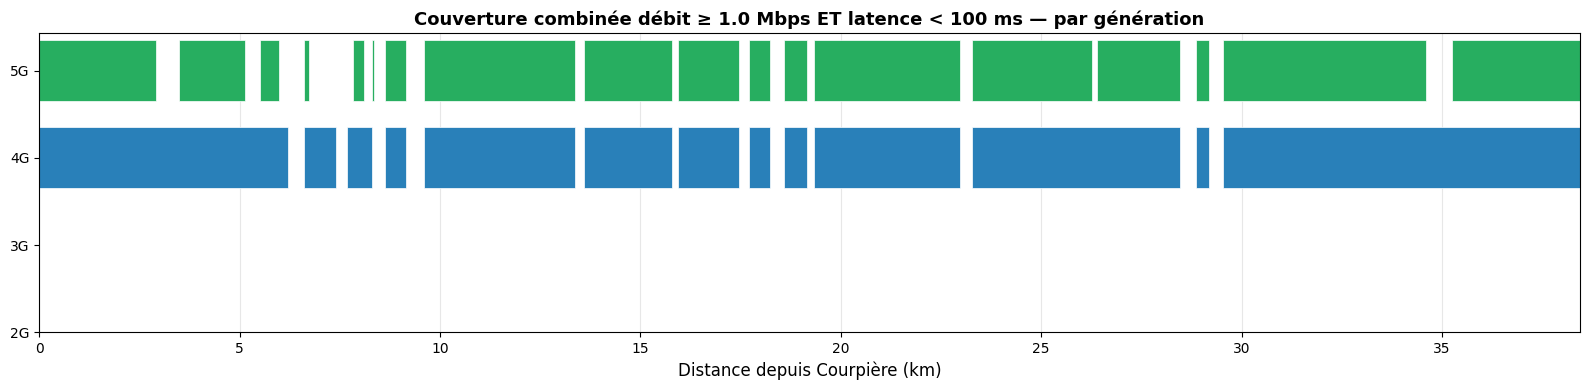

Sauvegardé : couverture_latence_100ms.png

Couverture par génération (débit ≥ 1.0 Mbps ET rtt < 100 ms) :
  2G :    0 points (  0.0% de la ligne)
  3G :    0 points (  0.0% de la ligne)
  4G : 1752 points ( 91.1% de la ligne)
  5G : 1608 points ( 83.6% de la ligne)


In [28]:
plot_couverture_latence(pivot_debit_rtt, seuil_latence_ms=100)

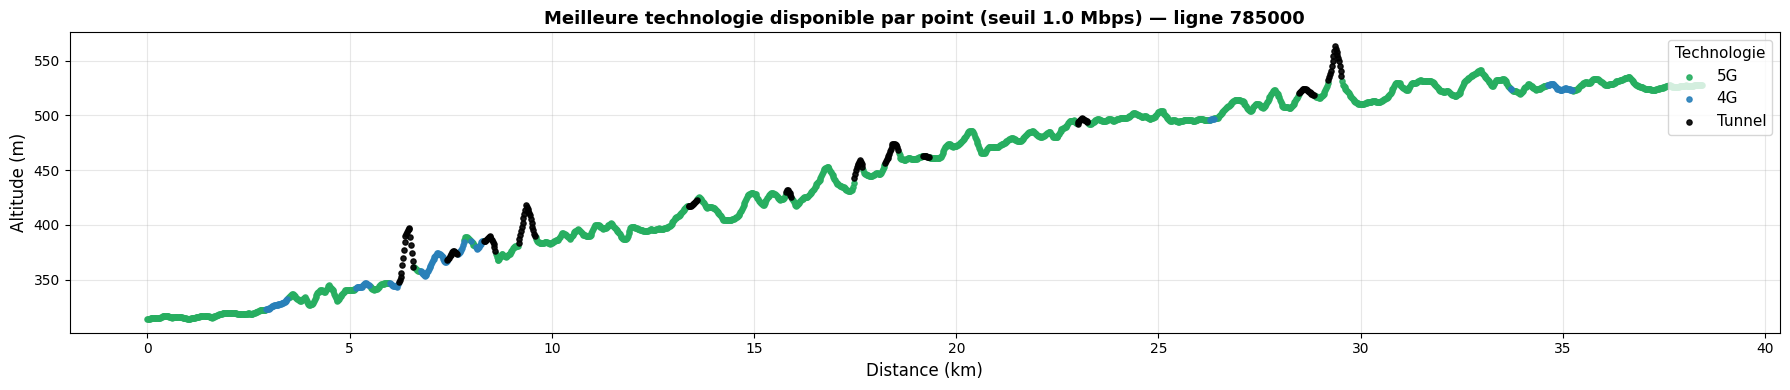


Distribution meilleure technologie par tronçon :
best_gen
5G        1608
Tunnel     171
4G         144
Name: count, dtype: int64
  5G       : 1608 points ( 83.6%) ≈ 32.2 km
  4G       :  144 points (  7.5%) ≈ 2.9 km
  3G       :    0 points (  0.0%) ≈ 0.0 km
  2G       :    0 points (  0.0%) ≈ 0.0 km
  Tunnel   :  171 points (  8.9%) ≈ 3.4 km
  Aucune   :    0 points (  0.0%) ≈ 0.0 km


In [29]:
# Quelle est la meilleure génération couvrant chaque point (seuil appliqué) ?
def best_gen(row):
    if row.get('in_tunnel', False):
        return 'Tunnel'
    for gen in ['5G', '4G', '3G', '2G']:
        if gen in row and row[gen] >= SEUIL_DEBIT_MBPS:
            return gen
    return 'Aucune'

pivot_debit['best_gen'] = pivot_debit.apply(best_gen, axis=1)

COLORS_MAP = {
    '5G'    : '#27ae60',
    '4G'    : '#2980b9',
    '3G'    : '#f39c12',
    '2G'    : '#e74c3c',
    'Tunnel': 'black',
    'Aucune': 'lightgray',
}

fig, ax = plt.subplots(figsize=(18, 4))
for gen, color in COLORS_MAP.items():
    mask = pivot_debit['best_gen'] == gen
    if not mask.any():
        continue
    ax.scatter(pivot_debit.loc[mask, 'distance_km'],
               pivot_debit.loc[mask, 'altitude_m'],
               c=color, s=14, alpha=0.9, label=gen, zorder=3)

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Altitude (m)', fontsize=12)
ax.set_title(f'Meilleure technologie disponible par point (seuil {SEUIL_DEBIT_MBPS} Mbps) — ligne 785000',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, title='Technologie', title_fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('couverture_carte_best_gen.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribution meilleure technologie par tronçon :")
print(pivot_debit['best_gen'].value_counts())
for gen in ['5G','4G','3G','2G','Tunnel','Aucune']:
    n   = (pivot_debit['best_gen'] == gen).sum()
    pct = n / len(pivot_debit) * 100
    km  = n * 0.02   # points espacés de ~20m
    print(f"  {gen:8s} : {n:4d} points ({pct:5.1f}%) ≈ {km:.1f} km")


## Tableau récapitulatif


In [30]:
print("=" * 65)
print(f"{'Technologie':<12} {'Points couverts':>16} {'% ligne':>8} {'Débit moy (Mbps)':>17} {'Débit max (Mbps)':>17}")
print("=" * 65)
for gen in ['2G','3G','4G','5G']:
    if gen not in pivot_debit.columns:
        continue
    mask = (pivot_debit[gen] >= SEUIL_DEBIT_MBPS) & (~pivot_debit['in_tunnel'])
    n    = mask.sum()
    pct  = n / len(pivot_debit) * 100
    moy  = pivot_debit.loc[mask, gen].mean()
    mx   = pivot_debit.loc[mask, gen].max()
    print(f"{gen:<12} {n:>16} {pct:>8.1f} {moy:>17.1f} {mx:>17.1f}")
print("=" * 65)
print(f"{'Tunnel':<12} {pivot_debit['in_tunnel'].sum():>16} "
      f"{pivot_debit['in_tunnel'].mean()*100:>8.1f}  {'—':>17} {'—':>17}")


Technologie   Points couverts  % ligne  Débit moy (Mbps)  Débit max (Mbps)
2G                          0      0.0               nan               nan
3G                       1730     90.0               6.9               7.2
4G                       1752     91.1              58.8              74.3
5G                       1608     83.6             217.8             298.3
Tunnel                    171      8.9                  —                 —


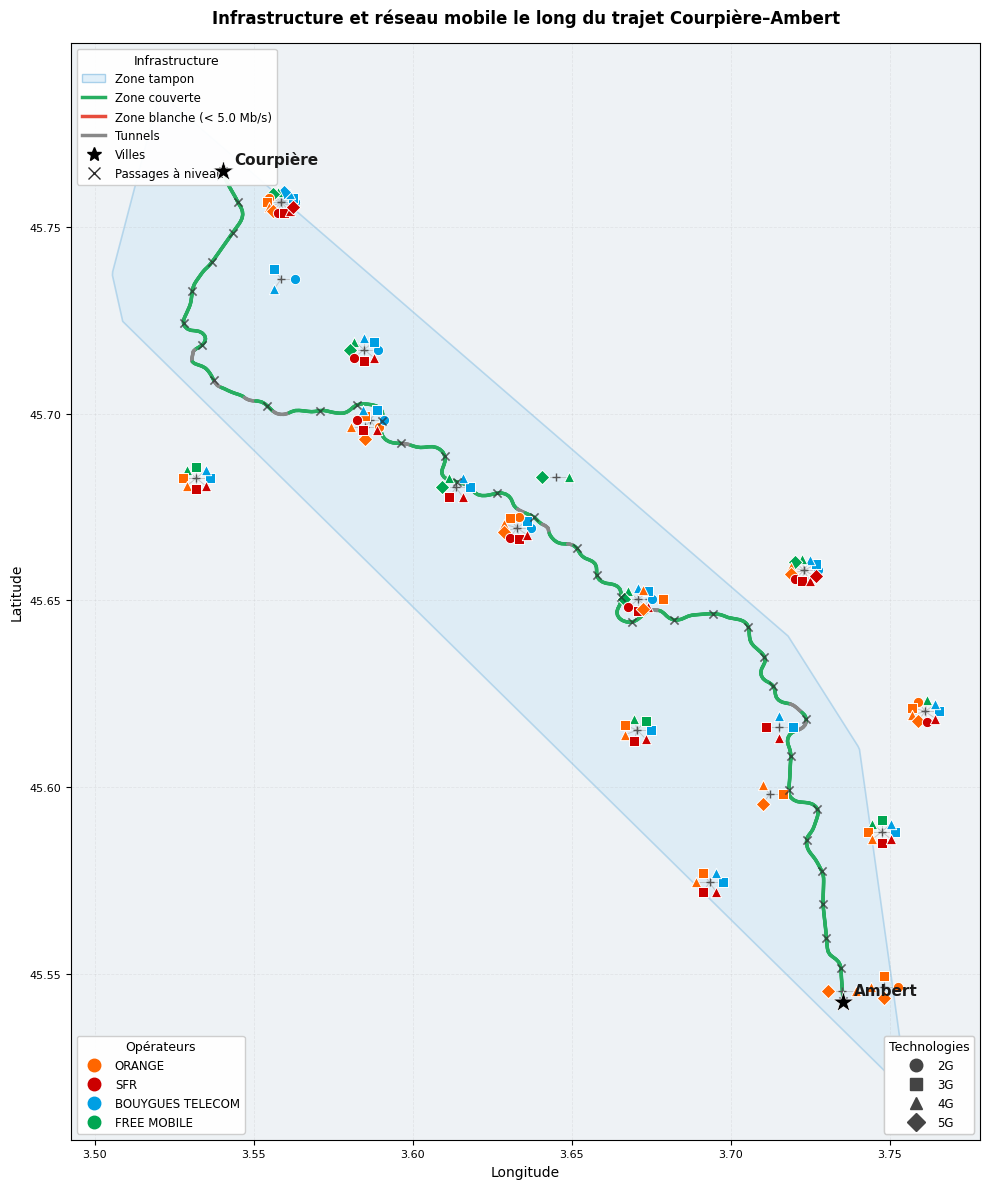

Carte générée — 125 marqueurs antennes (206 bruts dédupliqués → 125)


In [32]:
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon

SEUIL_DEBIT_MBPS = 5.0

# ── 1. Voie ferrée ────────────────────────────────────────────────────────────
voie = df.groupby('point_id').agg(
    lat         = ('lat',           'first'),
    lon         = ('lon',           'first'),
    distance_km = ('distance_km',   'first'),
    in_tunnel   = ('in_tunnel',     'first'),
    best_debit  = ('debit_adj_mbps','max'),
).reset_index().sort_values('distance_km')

voie['zone_blanche_carte'] = np.where(
    voie['in_tunnel'], 2,
    np.where(voie['best_debit'] < SEUIL_DEBIT_MBPS, 1, 0)
)

# ── 2. Antennes — dédupliquées par (support, opérateur, génération) ──────────
# FIX : le dataset a plusieurs lignes par ant_id (une par bande/scénario).
# On réduit à UNE entrée par (position_arrondie, opérateur, génération)
# pour éviter 31 marqueurs superposés sur le même pylône.
ant_raw = df.groupby('ant_id').agg(
    ant_lat   = ('ant_lat',   'first'),
    ant_lon   = ('ant_lon',   'first'),
    operateur = ('operateur', 'first'),
    generation= ('generation','first'),
).reset_index().dropna(subset=['ant_lat','ant_lon'])

ant_raw['pos_key'] = (ant_raw['ant_lat'].round(3).astype(str) + '_' +
                      ant_raw['ant_lon'].round(3).astype(str))

antennes = (ant_raw
    .groupby(['pos_key','operateur','generation'], as_index=False)
    .agg(ant_lat=('ant_lat','first'), ant_lon=('ant_lon','first'))
)

# ── 3. Palettes ───────────────────────────────────────────────────────────────
COLORS_OP = {
    'ORANGE':           '#FF6600',
    'SFR':              '#CC0000',
    'BOUYGUES TELECOM': '#009FE3',
    'FREE MOBILE':      '#00A651',
}
MARKERS_GEN = {'2G': 'o', '3G': 's', '4G': '^', '5G': 'D'}
COLOR_VOIE  = {0: '#27ae60', 1: '#e74c3c', 2: '#888888'}

# ── 4. Zone tampon (ConvexHull expansé autour du tracé) ──────────────────────
coords = voie[['lon','lat']].values
cx, cy = coords[:,0].mean(), coords[:,1].mean()
exp    = np.column_stack((
    cx + 1.20 * (coords[:,0] - cx),
    cy + 1.20 * (coords[:,1] - cy)
))
hull     = ConvexHull(exp)
hull_pts = exp[hull.vertices]
hull_pts = np.vstack([hull_pts, hull_pts[0]])

# ── 5. Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor('#eef2f5')
fig.patch.set_facecolor('white')

# Zone tampon
ax.add_patch(MplPolygon(hull_pts, closed=True,
    facecolor='#cce5f6', edgecolor='#7ab8e0',
    lw=1.2, alpha=0.45, zorder=1))

# Voie ferrée colorée segment par segment
for i in range(len(voie) - 1):
    r, r2 = voie.iloc[i], voie.iloc[i+1]
    ax.plot([r['lon'], r2['lon']], [r['lat'], r2['lat']],
            color=COLOR_VOIE[r['zone_blanche_carte']],
            lw=2.5, zorder=3, solid_capstyle='round')

# ── 6. Antennes — système radial pour supports co-localisés ──────────────────
# FIX aspect ratio : 1 degré lon ≠ 1 degré lat à cette latitude
lat_mean = voie['lat'].mean()
aspect   = np.cos(np.radians(lat_mean))   # ~0.699
R_ORBIT  = 0.003   # rayon en degrés lat — appliqué correctement ci-dessous

for pos_key, group in antennes.groupby('pos_key'):
    clat = group['ant_lat'].iloc[0]
    clon = group['ant_lon'].iloc[0]
    n    = len(group)

    if n == 1:
        row = group.iloc[0]
        ax.scatter(clon, clat,
                   marker=MARKERS_GEN.get(row['generation'], 'o'),
                   color=COLORS_OP.get(row['operateur'], '#888888'),
                   s=70, zorder=6, edgecolors='white', linewidths=0.8)
    else:
        # Point central = pylône partagé
        ax.scatter(clon, clat, marker='+', color='#555555',
                   s=40, zorder=5, linewidths=1.0)
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        for idx, (_, row) in enumerate(group.iterrows()):
            # FIX : corriger l'aspect ratio sur la longitude
            orb_lon = clon + (R_ORBIT / aspect) * np.cos(angles[idx])
            orb_lat = clat + R_ORBIT             * np.sin(angles[idx])
            ax.plot([clon, orb_lon], [clat, orb_lat],
                    color='#aaaaaa', lw=0.7, zorder=4, alpha=0.6)
            ax.scatter(orb_lon, orb_lat,
                       marker=MARKERS_GEN.get(row['generation'], 'o'),
                       color=COLORS_OP.get(row['operateur'], '#888888'),
                       s=55, zorder=6, edgecolors='white', linewidths=0.7)

# ── 7. Villes ─────────────────────────────────────────────────────────────────
for ville, (lat, lon) in [
    ('Courpière', (voie.iloc[0]['lat'],  voie.iloc[0]['lon'])),
    ('Ambert',    (voie.iloc[-1]['lat'], voie.iloc[-1]['lon'])),
]:
    ax.scatter(lon, lat, marker='*', color='black', s=250, zorder=8,
               edgecolors='white', linewidths=0.5)
    ax.annotate(ville, (lon, lat), textcoords='offset points',
                xytext=(8, 5), fontsize=11, fontweight='bold',
                color='#1a1a1a', zorder=9)

# ── 8. Passages à niveau (approximés tous les ~1 km hors tunnel) ──────────────
pn = voie[~voie['in_tunnel']].iloc[::50]   # ~1 point / km à 20m d'espacement
ax.scatter(pn['lon'], pn['lat'], marker='x', color='#2c2c2c',
           s=35, lw=1.2, zorder=7, alpha=0.7)

# ── 9. Légendes ───────────────────────────────────────────────────────────────
leg1 = ax.legend(handles=[
    mpatches.Patch(facecolor='#cce5f6', edgecolor='#7ab8e0',
                   label='Zone tampon', alpha=0.6),
    Line2D([0],[0], color='#27ae60', lw=2.5, label='Zone couverte'),
    Line2D([0],[0], color='#e74c3c', lw=2.5,
           label=f'Zone blanche (< {SEUIL_DEBIT_MBPS} Mb/s)'),
    Line2D([0],[0], color='#888888', lw=2.5, label='Tunnels'),
    Line2D([0],[0], marker='*', color='black', linestyle='None',
           markersize=10, label='Villes'),
    Line2D([0],[0], marker='x', color='#2c2c2c', linestyle='None',
           markersize=8, label='Passages à niveau'),
], title='Infrastructure', loc='upper left',
   fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg1)

leg2 = ax.legend(handles=[
    Line2D([0],[0], marker='o', color=c, linestyle='None',
           markersize=9, label=op)
    for op, c in COLORS_OP.items()
], title='Opérateurs', loc='lower left',
   fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg2)

leg3 = ax.legend(handles=[
    Line2D([0],[0], marker=m, color='#444444', linestyle='None',
           markersize=9, label=gen)
    for gen, m in MARKERS_GEN.items()
], title='Technologies', loc='lower right',
   fontsize=8.5, title_fontsize=9, framealpha=0.95)
ax.add_artist(leg3)

# ── 10. Mise en page ──────────────────────────────────────────────────────────
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude',  fontsize=10)
ax.set_title('Infrastructure et réseau mobile le long du trajet Courpière–Ambert',
             fontsize=12, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, linestyle='--', lw=0.6)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('carte_reseau_mobile_ligne785000.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Carte générée — {len(antennes)} marqueurs antennes '
      f'({len(ant_raw)} bruts dédupliqués → {len(antennes)})')